In [11]:
import os
# the notebook runs from its own directory; nothing to chdir to
import numpy as np
import matplotlib.pyplot as plt
from darcy_solver import DarcySolver, convergence_test
from GRF import GaussianRF
from UKI import UKI_np, EKI
import time

# Inverse Problem: Adjoint vs PINN vs EKI with Sparse Observations

Recover the log-permeability field $m$ from sparse noisy pressure observations using three methods:
1. **Adjoint-based inversion** — optimize Gaussian-random-field coefficient parameters and map them to the elementwise permeability field
2. **PINN** — jointly learn $u_\theta$ and $m_\phi$ via a physics-informed loss
3. **EKI** — perform ensemble Kalman inversion in the same GRF coefficient space

**Common setup:**
- True $m$ sampled from a Gaussian Random Field with $\tau = 3$, $\alpha = 2$, and 128 KL modes
- Forcing: $f(x,y) = 100$
- Observation grid: $9 \times 9$ interior points with margin $0.1$
- Noise model: $y_{\text{noisy}} = P u_{\text{true}} + \varepsilon$, with $\varepsilon \sim \mathcal{N}(0, (0.01 \max |u|)^2 I)$

## 1. Import Dependencies and Inverse Solvers

Load the Darcy solver, GRF and inversion utilities, then import the adjoint module used for the reference inverse solve.

In [12]:
# Import adjoint solver (reload if already imported)
import importlib
import darcy_adjoint
importlib.reload(darcy_adjoint)
from darcy_adjoint import DarcyInverse, run_adjoint_inversion, create_observation_grid, save_adjoint_results

## 2. Optional Solver Convergence Check

This disabled cell verifies the spatial convergence rate of the P2 Darcy FEM solver with a manufactured solution.

In [5]:
if False:
    # Verify spatial convergence of the P2 FEM solver (manufactured solution)
    results = convergence_test(
        mesh_sizes=[8, 16, 32, 64],
        alpha=0.5,
        element_degree=2,
        solver_type='direct',
        verbose=True
    )

    # Plot convergence rates
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    h = np.array(results['h'])

    ax = axes[0]
    ax.loglog(h, results['error_L2'], 'bo-', linewidth=2, label='$L^2$ error')
    ax.loglog(h, results['error_L2'][0]*(h/h[0])**3, 'b--', alpha=0.5, label='$O(h^3)$ ref')
    ax.set_xlabel('$h$', fontsize=13)
    ax.set_ylabel('Error', fontsize=13)
    ax.set_title('$L^2$ Convergence', fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.loglog(h, results['error_H1'], 'ro-', linewidth=2, label='$H^1$ error')
    ax.loglog(h, results['error_H1'][0]*(h/h[0])**2, 'r--', alpha=0.5, label='$O(h^2)$ ref')
    ax.set_xlabel('$h$', fontsize=13)
    ax.set_ylabel('Error', fontsize=13)
    ax.set_title('$H^1$ Convergence', fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.suptitle('P2 FEM Solver Convergence (Manufactured Solution)', fontsize=14)
    plt.tight_layout()
    plt.show()

    print(f"\nExpected rates: L2 ~ 3.0, H1 ~ 2.0 for P2 elements")
    print(f"Observed L2 rates: {results['rate_L2']}")
    print(f"Observed H1 rates: {results['rate_H1']}")
    """ 
    Mesh: 8×8
    ----------------------------------------------------------------------
    Mesh: 8×8, h=1.2500e-01
    DOFs: 289
    Assembly time: 0.0896s
    Solve time: 0.0004s
    L2 error:  4.777925e-04
    H1 error:  3.346822e-02

    Mesh: 16×16
    ----------------------------------------------------------------------
    Mesh: 16×16, h=6.2500e-02
    DOFs: 1089
    Assembly time: 0.3033s
    Solve time: 0.0022s
    L2 error:  5.965502e-05
    H1 error:  8.425635e-03

    Mesh: 32×32
    ----------------------------------------------------------------------
    Mesh: 32×32, h=3.1250e-02
    DOFs: 4225
    Assembly time: 1.2038s
    Solve time: 0.0148s
    L2 error:  7.453457e-06
    H1 error:  2.109966e-03

    Mesh: 64×64
    ----------------------------------------------------------------------
    Mesh: 64×64, h=1.5625e-02
    DOFs: 16641
    Assembly time: 5.7459s
    Solve time: 0.1021s
    L2 error:  9.315662e-07
    H1 error:  5.277120e-04

    ======================================================================
    CONVERGENCE SUMMARY
    ======================================================================
    h            DOFs     L2 error       L2 rate    H1 error       H1 rate   
    ----------------------------------------------------------------------
    1.2500e-01   289      4.777925e-04   ---        3.346822e-02   ---       
    6.2500e-02   1089     5.965502e-05   3.002      8.425635e-03   1.990     
    3.1250e-02   4225     7.453457e-06   3.001      2.109966e-03   1.998     
    1.5625e-02   16641    9.315662e-07   3.000      5.277120e-04   1.999     
    ----------------------------------------------------------------------
    Average L2 rate: 3.001 (expected: 3 for P2)
    Average H1 rate: 1.996 (expected: 2 for P2)
    ======================================================================

    Expected rates: L2 ~ 3.0, H1 ~ 2.0 for P2 elements
    Observed L2 rates: [3.00166866 3.00066204 3.00017939]
    Observed H1 rates: [1.9899346  1.99756545 1.99939716]
    """

## 3. Configure the Sparse-Observation Inverse Problem

Set the mesh, forcing, observation layout, noise model, regularization weights, and optimization controls shared by the inverse solvers.

In [13]:
# ============================================================================
# CONTROL VARIABLES - Modify these to adjust the inverse problem
# ============================================================================

# Mesh parameters
nx_inv = 32        # Number of cells in x-direction
ny_inv = 32        # Number of cells in y-direction
element_degree = 2 # Polynomial degree (1=P1, 2=P2)
#for 32+P2: L2 error:  7.453457e-06    H1 error:  2.109966e-03

# Forcing function f(x,y)
# f_given = lambda x, y: np.sin(2*np.pi*x) * np.sin(2*np.pi*y)
f_given = lambda x, y: 100 * np.ones_like(x)

# True permeability pattern
# Piecewise: 'rectangles', 'disks', 'checkerboard', 'layered', 'random_inclusions'
# Smooth: 'smooth_sine', 'smooth_gaussian', 'smooth_peaks', 'smooth_radial', 'smooth_polynomial'
m_true_pattern = 'smooth_sine'

# Pattern-specific parameters (optional)
pattern_params = {
    'amplitude': 0.8,  # For smooth_sine
    'kx': 1,           # Number of periods in x
    'ky': 1            # Number of periods in y
}

# ============================================================================
# OBSERVATION CONFIGURATION - 6x6 sparse grid
# ============================================================================
N_OBS_X = 9  # Number of observations in x
N_OBS_Y = 9  # Number of observations in y
OBS_MARGIN = 0.1  # Margin from boundaries

# Create observation grid
obs_points = create_observation_grid(n_x=N_OBS_X, n_y=N_OBS_Y, margin=OBS_MARGIN)
print(f"Observation grid: {N_OBS_X}×{N_OBS_Y} = {len(obs_points)} points")
print(f"Observation locations (interior, margin={OBS_MARGIN}):")
print(f"  x ∈ [{obs_points[:, 0].min():.2f}, {obs_points[:, 0].max():.2f}]")
print(f"  y ∈ [{obs_points[:, 1].min():.2f}, {obs_points[:, 1].max():.2f}]")

# ============================================================================
# NOISE CONFIGURATION - 1% of max value
# ============================================================================
NOISE_LEVEL = 0.01  # 1% noise
NOISE_TYPE = 'max'  # Noise as percentage of max(|u|)
NOISE_SEED = 42     # Random seed for reproducibility

# ============================================================================
# REGULARIZATION PARAMETERS
# ============================================================================
# Tikhonov (L2) regularization: penalizes ||m||^2
beta = 0 

# Sobolev (H1) regularization: penalizes ||∇m||^2 (encourages smooth m)
gamma = 0.001 # Set to 0 to disable

# Optimization parameters
max_iter = 500
opt_method = 'SSBroyden2'  # Same as PINN (requires patched scipy)

# Solver type ('direct' or 'amg')
linear_solver = 'direct'

print("\nInverse problem configuration:")
print(f"  Mesh: {nx_inv}×{ny_inv} (P{element_degree})")
print(f"  True pattern: {m_true_pattern}")
print(f"  Observations: {len(obs_points)} sparse points ({N_OBS_X}×{N_OBS_Y} grid)")
print(f"  Noise level: {NOISE_LEVEL*100:.1f}% of max(|u|)")
print(f"  Noise seed: {NOISE_SEED}")
print(f"  Regularization: β (L2) = {beta:.2e}, γ (H1) = {gamma:.2e}")
print(f"  Max iterations: {max_iter}")

Observation grid: 9×9 = 81 points
Observation locations (interior, margin=0.1):
  x ∈ [0.10, 0.90]
  y ∈ [0.10, 0.90]

Inverse problem configuration:
  Mesh: 32×32 (P2)
  True pattern: smooth_sine
  Observations: 81 sparse points (9×9 grid)
  Noise level: 1.0% of max(|u|)
  Noise seed: 42
  Regularization: β (L2) = 0.00e+00, γ (H1) = 1.00e-03
  Max iterations: 500


## 4. Generate Reference Data and Noisy Observations

Build the Darcy inverse solver, sample the GRF reference permeability field, generate sparse noisy observations, and visualize the reference field and observation noise.

In [14]:
# Create the inverse solver with sparse observations
inv = DarcyInverse(
    nx=nx_inv, ny=ny_inv, 
    element_degree=element_degree,
    f_given=f_given,
    beta=beta,
    gamma=gamma,  # Sobolev (H1) regularization
    solver_type=linear_solver,
    obs_points=obs_points  # Sparse observation points
)

print(f"Inverse solver created:")
print(f"  DOFs: {inv.n_dofs}")
print(f"  Elements: {inv.n_elements}")
print(f"  Observation points: {inv.n_obs}")
print(f"  Internal edges: {inv.n_internal_edges} (for H1 regularization)")

# Generate reference permeability field (smooth or piecewise)
# m_true = inv.generate_reference_m(pattern=m_true_pattern, **pattern_params)
kappa_mesh = inv.element_centroids
RF = GaussianRF(3, 2)
np.random.seed(1234)
coefs = np.random.randn(128)
m_true = RF.sample(kappa_mesh, coefs).flatten()


print(f"\nReference field m†:")
print(f"  min(m†) = {np.min(m_true):.4f}")
print(f"  max(m†) = {np.max(m_true):.4f}")
print(f"  mean(m†) = {np.mean(m_true):.4f}")
print(f"  std(m†) = {np.std(m_true):.4f}")
print(f"  k_min = exp(min(m)) = {np.exp(np.min(m_true)):.4f}")
print(f"  k_max = exp(max(m)) = {np.exp(np.max(m_true)):.4f}")

# Generate observations WITH NOISE (1% of max value)
y_obs, u_clean = inv.generate_observations(
    m_true, 
    noise_level=NOISE_LEVEL, 
    noise_type=NOISE_TYPE,
    seed=NOISE_SEED
)

# Also get clean observations for comparison
y_clean = inv.observe(u_clean)

print(f"\nObservations (with {NOISE_LEVEL*100:.0f}% noise of max|u|):")
print(f"  max(|u_clean|) = {np.max(np.abs(u_clean)):.6e}")
print(f"  Noise magnitude = {NOISE_LEVEL * np.max(np.abs(u_clean)):.6e}")
print(f"  ||y_obs - y_clean||_2 / ||y_clean||_2 = {np.linalg.norm(y_obs - y_clean) / np.linalg.norm(y_clean) * 100:.2f}%")
print(f"  Actual noise std = {np.std(y_obs - y_clean):.6e}")

Observation operator created: 81 observation points
Inverse solver created:
  DOFs: 4225
  Elements: 2048
  Observation points: 81
  Internal edges: 3008 (for H1 regularization)

Reference field m†:
  min(m†) = -0.8609
  max(m†) = 0.6184
  mean(m†) = 0.0000
  std(m†) = 0.2884
  k_min = exp(min(m)) = 0.4228
  k_max = exp(max(m)) = 1.8559

Observations (with 1% noise of max|u|):
  max(|u_clean|) = 7.377173e+00
  Noise magnitude = 7.377173e-02
  ||y_obs - y_clean||_2 / ||y_clean||_2 = 1.24%
  Actual noise std = 5.652705e-02


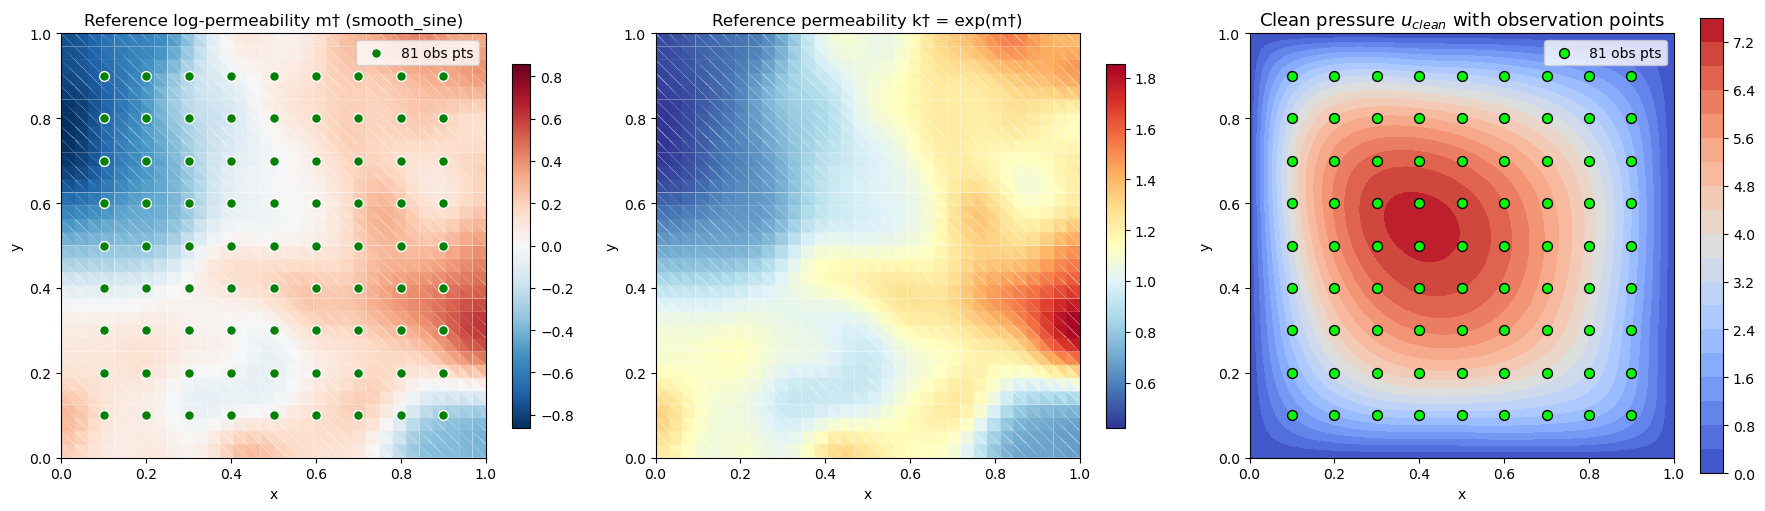


Permeability statistics:
  Background k₀ = 1.0777
  k_min = 0.4228
  k_max = 1.8559
  Contrast ratio k_max/k_min = 4.39


In [8]:
# Plot the reference permeability field and observation points
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# True m field (log-permeability)
inv.plot_elementwise_field(m_true, ax=axes[0], cmap='RdBu_r',
                           title=f'Reference log-permeability m† ({m_true_pattern})')
# Plot observation points
axes[0].scatter(obs_points[:, 0], obs_points[:, 1], c='green', s=50, marker='o', 
                edgecolors='white', linewidths=1, label=f'{len(obs_points)} obs pts')
axes[0].legend(loc='upper right')

# True k = exp(m) field
k_true = np.exp(m_true)
inv.plot_elementwise_field(k_true, ax=axes[1], cmap='RdYlBu_r',
                           title=f'Reference permeability k† = exp(m†)')

# Full pressure field with observation points
from scipy.interpolate import griddata
n_plot = 100
x_plot = np.linspace(0, 1, n_plot)
y_plot = np.linspace(0, 1, n_plot)
X_plot, Y_plot = np.meshgrid(x_plot, y_plot)
u_clean_grid = griddata(inv.nodes, u_clean, (X_plot, Y_plot), method='linear')

im = axes[2].contourf(X_plot, Y_plot, u_clean_grid, levels=20, cmap='coolwarm')
axes[2].scatter(obs_points[:, 0], obs_points[:, 1], c='lime', s=50, marker='o',
                edgecolors='black', linewidths=1, label=f'{len(obs_points)} obs pts')
axes[2].set_title('Clean pressure $u_{clean}$ with observation points', fontsize=13)
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].set_aspect('equal')
axes[2].legend(loc='upper right')
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
# plt.savefig('figures/reference_and_obs_points.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPermeability statistics:")
print(f"  Background k₀ = {np.median(k_true):.4f}")
print(f"  k_min = {np.min(k_true):.4f}")
print(f"  k_max = {np.max(k_true):.4f}")
print(f"  Contrast ratio k_max/k_min = {np.max(k_true)/np.min(k_true):.2f}")

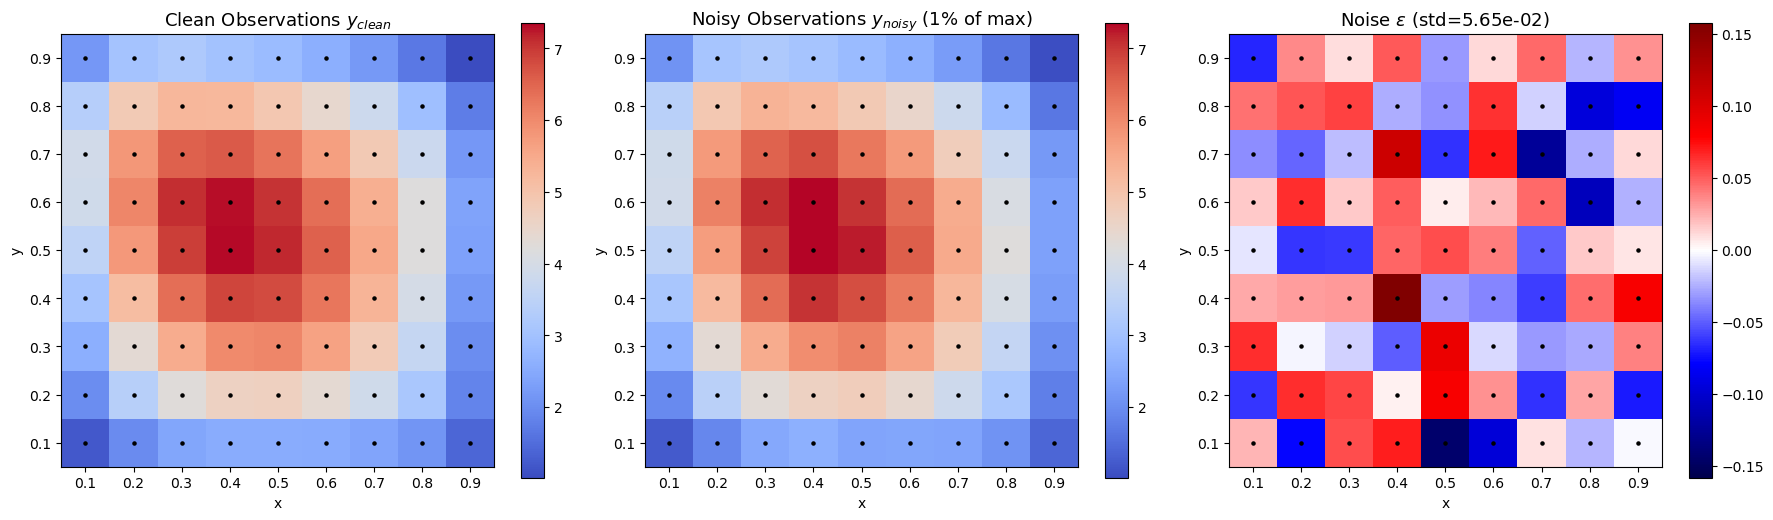


Noise statistics:
  ||noise||_2 / ||y_clean||_2 = 1.24%
  max|noise| = 1.5799e-01
  std(noise) = 5.6527e-02


In [9]:
# Visualize: Clean vs Noisy observations at sparse points
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Reshape observations to 2D grid for visualization
y_clean_2d = y_clean.reshape(N_OBS_Y, N_OBS_X)
y_obs_2d = y_obs.reshape(N_OBS_Y, N_OBS_X)
noise_2d = (y_obs - y_clean).reshape(N_OBS_Y, N_OBS_X)

x_obs_1d = np.linspace(OBS_MARGIN, 1-OBS_MARGIN, N_OBS_X)
y_obs_1d = np.linspace(OBS_MARGIN, 1-OBS_MARGIN, N_OBS_Y)
X_obs, Y_obs = np.meshgrid(x_obs_1d, y_obs_1d)

# Clean observations
vmin_obs = min(y_clean.min(), y_obs.min())
vmax_obs = max(y_clean.max(), y_obs.max())

im0 = axes[0].pcolormesh(X_obs, Y_obs, y_clean_2d, cmap='coolwarm', 
                         vmin=vmin_obs, vmax=vmax_obs, shading='auto')
axes[0].scatter(obs_points[:, 0], obs_points[:, 1], c='black', s=20, marker='.')
axes[0].set_title('Clean Observations $y_{clean}$', fontsize=13)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_aspect('equal')
plt.colorbar(im0, ax=axes[0])

# Noisy observations
im1 = axes[1].pcolormesh(X_obs, Y_obs, y_obs_2d, cmap='coolwarm', 
                         vmin=vmin_obs, vmax=vmax_obs, shading='auto')
axes[1].scatter(obs_points[:, 0], obs_points[:, 1], c='black', s=20, marker='.')
axes[1].set_title(f'Noisy Observations $y_{{noisy}}$ ({NOISE_LEVEL*100:.0f}% of max)', fontsize=13)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_aspect('equal')
plt.colorbar(im1, ax=axes[1])

# Noise
vmax_noise = np.max(np.abs(noise_2d))
im2 = axes[2].pcolormesh(X_obs, Y_obs, noise_2d, cmap='seismic', 
                         vmin=-vmax_noise, vmax=vmax_noise, shading='auto')
axes[2].scatter(obs_points[:, 0], obs_points[:, 1], c='black', s=20, marker='.')
axes[2].set_title(f'Noise $\\varepsilon$ (std={np.std(y_obs - y_clean):.2e})', fontsize=13)
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].set_aspect('equal')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.savefig('figures/clean_vs_noisy_obs_sparse.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nNoise statistics:")
print(f"  ||noise||_2 / ||y_clean||_2 = {np.linalg.norm(y_obs - y_clean) / np.linalg.norm(y_clean) * 100:.2f}%")
print(f"  max|noise| = {np.max(np.abs(y_obs - y_clean)):.4e}")
print(f"  std(noise) = {np.std(y_obs - y_clean):.4e}")

## 5. Check and Run the Adjoint Inversion

First verify the GRF-space adjoint gradient with finite differences, then optimize the GRF coefficients with BFGS to recover the permeability field.

In [15]:
# Finite-difference check of the GRF-space adjoint gradient
gc_required = ['coefs', 'RF', 'kappa_mesh', 'inv', 'y_obs', 'np']
gc_missing = [gc_name for gc_name in gc_required if gc_name not in globals()]

if gc_missing:
    print('Run the setup and data-generation cells above before this gradient check cell.')
    print('Missing state:', ', '.join(gc_missing))
else:
    gc_r = coefs.shape[0]
    gc_sigma_grf = RF.sigma if RF.sigma is not None else RF.tau ** (0.5 * (2 * RF.alpha - 2))
    gc_sqrt_eigs, gc_kl_points = RF._eigen_val_and_points(gc_r, 2, gc_sigma_grf)
    gc_Phi = RF._eigen_funcs(gc_kl_points, kappa_mesh)
    gc_scaled_Phi = gc_sqrt_eigs[:, None] * gc_Phi
    gc_xi = coefs.copy()
    gc_rng = np.random.default_rng(0)
    gc_direction = gc_rng.standard_normal(gc_r)
    gc_direction /= np.linalg.norm(gc_direction)

    def gc_objective_and_gradient_xi(xi):
        gc_m = gc_scaled_Phi.T @ xi
        gc_J, gc_grad_m, _, _ = inv.objective_and_gradient(gc_m, y_obs)
        gc_grad_xi = gc_scaled_Phi @ gc_grad_m
        return gc_J, gc_grad_xi

    gc_J0, gc_grad0 = gc_objective_and_gradient_xi(gc_xi)
    gc_dir_deriv = float(gc_grad0 @ gc_direction)
    gc_steps = np.array([1e-1, 3e-2, 1e-2, 3e-3, 1e-3, 3e-4, 1e-4], dtype=np.float64)

    print('Gradient check in xi-space: central difference vs adjoint directional derivative')
    print(f'Base objective J(xi) = {gc_J0:.6e}')
    print(f'Adjoint directional derivative = {gc_dir_deriv:.6e}')
    print(f"{'eps':>10} {'FD deriv':>16} {'abs err':>12} {'rel err':>12}")
    for gc_eps in gc_steps:
        gc_J_plus, _ = gc_objective_and_gradient_xi(gc_xi + gc_eps * gc_direction)
        gc_J_minus, _ = gc_objective_and_gradient_xi(gc_xi - gc_eps * gc_direction)
        gc_fd = (gc_J_plus - gc_J_minus) / (2.0 * gc_eps)
        gc_abs_err = abs(gc_fd - gc_dir_deriv)
        gc_rel_err = gc_abs_err / max(abs(gc_fd), abs(gc_dir_deriv), 1e-16)
        print(f'{gc_eps:10.1e} {gc_fd:16.8e} {gc_abs_err:12.3e} {gc_rel_err:12.3e}')

Gradient check in xi-space: central difference vs adjoint directional derivative
Base objective J(xi) = 1.678951e-01
Adjoint directional derivative = 7.708878e-03
       eps         FD deriv      abs err      rel err
   1.0e-01   7.70863014e-03    2.481e-07    3.218e-05
   3.0e-02   7.70885590e-03    2.233e-08    2.896e-06
   1.0e-02   7.70887575e-03    2.482e-09    3.219e-07
   3.0e-03   7.70887801e-03    2.204e-10    2.859e-08
   1.0e-03   7.70887821e-03    1.596e-11    2.070e-09
   3.0e-04   7.70887821e-03    1.911e-11    2.478e-09
   1.0e-04   7.70887833e-03    1.048e-10    1.359e-08


In [42]:

# Adjoint inversion in GRF coefficient space (same parameterization as EKI)
# m(xi) = (xi * sqrt_eigs) @ Phi,  grad_xi = Phi.T @ diag(sqrt_eigs) @ grad_m
from scipy.optimize import minimize as sp_minimize

# Precompute the GRF basis: Phi (r, N_elem) and sqrt_eigs (r,)
r = coefs.shape[0]  # 128
sigma_grf = RF.sigma if RF.sigma is not None else RF.tau ** (0.5 * (2 * RF.alpha - 2))
sqrt_eigs, kl_points = RF._eigen_val_and_points(r, 2, sigma_grf)
Phi = RF._eigen_funcs(kl_points, kappa_mesh)  # (r, N_elem)
# Precompute scaled basis: diag(sqrt_eigs) @ Phi -> (r, N_elem)
scaled_Phi = sqrt_eigs[:, None] * Phi  # (r, N_elem)

# Verify: RF.sample(kappa_mesh, coefs) == (coefs * sqrt_eigs) @ Phi
m_check = (coefs[None, :] * sqrt_eigs[None, :]) @ Phi
print(f"GRF basis check: ||m_true - m_check|| = {np.linalg.norm(m_true - m_check.flatten()):.2e}")

t_start = time.time()
xi0 = np.zeros(r, dtype=np.float64)  # Initial coefficients

# History tracking
inv.history = {'J': [], 'grad_norm': [], 'm_norm': [],
               'data_misfit': [], 'reg_term': [], 'm_error': []}
adj_iter = [0]

def obj_and_grad_xi(xi):
    # Map xi -> m
    m = scaled_Phi.T @ xi  # (N_elem,)
    
    # Forward solve + gradient in m-space
    J, grad_m, mis, reg = inv.objective_and_gradient(m, y_obs)
    
    # Chain rule: grad_xi = scaled_Phi @ grad_m
    grad_xi = scaled_Phi @ grad_m  # (r,)
    
    m_error = np.linalg.norm(m - m_true) / np.linalg.norm(m_true)
    
    # Track history
    inv.history['J'].append(J)
    inv.history['grad_norm'].append(np.linalg.norm(grad_xi))
    inv.history['m_norm'].append(np.linalg.norm(m))
    inv.history['data_misfit'].append(mis)
    inv.history['reg_term'].append(reg)
    inv.history['m_error'].append(m_error)
    
    if adj_iter[0] % 10 == 0:
        print(f"  iter {adj_iter[0]:4d}: J={J:.6e}, |g|={np.linalg.norm(grad_xi):.3e}, "
              f"misfit={mis:.3e}, m_err={m_error*100:.2f}%")
    adj_iter[0] += 1
    return J, grad_xi

H0 = np.eye(r)
opt_result = sp_minimize(
    fun=obj_and_grad_xi, x0=xi0, jac=True, method='BFGS',
    options=dict(
        #maxiter=max_iter,
        maxiter=50,
        gtol=0.0,
        disp=False,
        method_bfgs='SSBroyden2',
        hess_inv0=H0,
        initial_scale=False,
    ),
)
xi_rec = opt_result.x
m_rec = scaled_Phi.T @ xi_rec  # Recover m from optimal xi
t_total = time.time() - t_start

rel_error = np.linalg.norm(m_rec - m_true) / np.linalg.norm(m_true)
coef_error = np.linalg.norm(xi_rec - coefs) / np.linalg.norm(coefs)
print(f"\n" + "="*70)
print(f"RECONSTRUCTION RESULTS (GRF-parameterized Adjoint)")
print(f"="*70)
print(f"  Total time: {t_total:.2f}s")
print(f"  Final objective: {opt_result.fun:.6e}")
print(f"  Iterations: {opt_result.nit}")
print(f"  Relative L2 error ||m_rec - m†||/||m†||: {rel_error*100:.2f}%")
print(f"  GRF coef error ||xi_rec - xi†||/||xi†||: {coef_error*100:.2f}%")
print(f"  Optimization dim: {r} (GRF coefficients) vs {inv.n_elements} (elementwise)")


GRF basis check: ||m_true - m_check|| = 0.00e+00
  iter    0: J=1.440282e+01, |g|=1.561e+01, misfit=1.440e+01, m_err=100.00%
  iter   10: J=2.317292e-01, |g|=1.235e-01, misfit=2.179e-01, m_err=32.33%
  iter   20: J=1.304640e-01, |g|=3.402e-01, misfit=1.073e-01, m_err=22.73%
  iter   30: J=9.546655e-02, |g|=9.122e-02, misfit=6.758e-02, m_err=25.30%
  iter   40: J=8.436438e-02, |g|=3.280e-02, misfit=5.338e-02, m_err=27.61%
  iter   50: J=8.284574e-02, |g|=3.153e-02, misfit=5.178e-02, m_err=26.10%
  iter   60: J=8.192888e-02, |g|=1.071e-02, misfit=5.050e-02, m_err=26.54%
  iter   70: J=8.192888e-02, |g|=1.071e-02, misfit=5.050e-02, m_err=26.54%
  iter   80: J=8.192888e-02, |g|=1.071e-02, misfit=5.050e-02, m_err=26.54%
  iter   90: J=8.192888e-02, |g|=1.071e-02, misfit=5.050e-02, m_err=26.54%
  iter  100: J=8.192895e-02, |g|=1.069e-02, misfit=5.050e-02, m_err=26.54%

RECONSTRUCTION RESULTS (GRF-parameterized Adjoint)
  Total time: 3.04s
  Final objective: 8.192888e-02
  Iterations: 43
  Re

## 6. Visualize the Adjoint Reconstruction

Compare the recovered permeability field and its forward solution against the reference data.

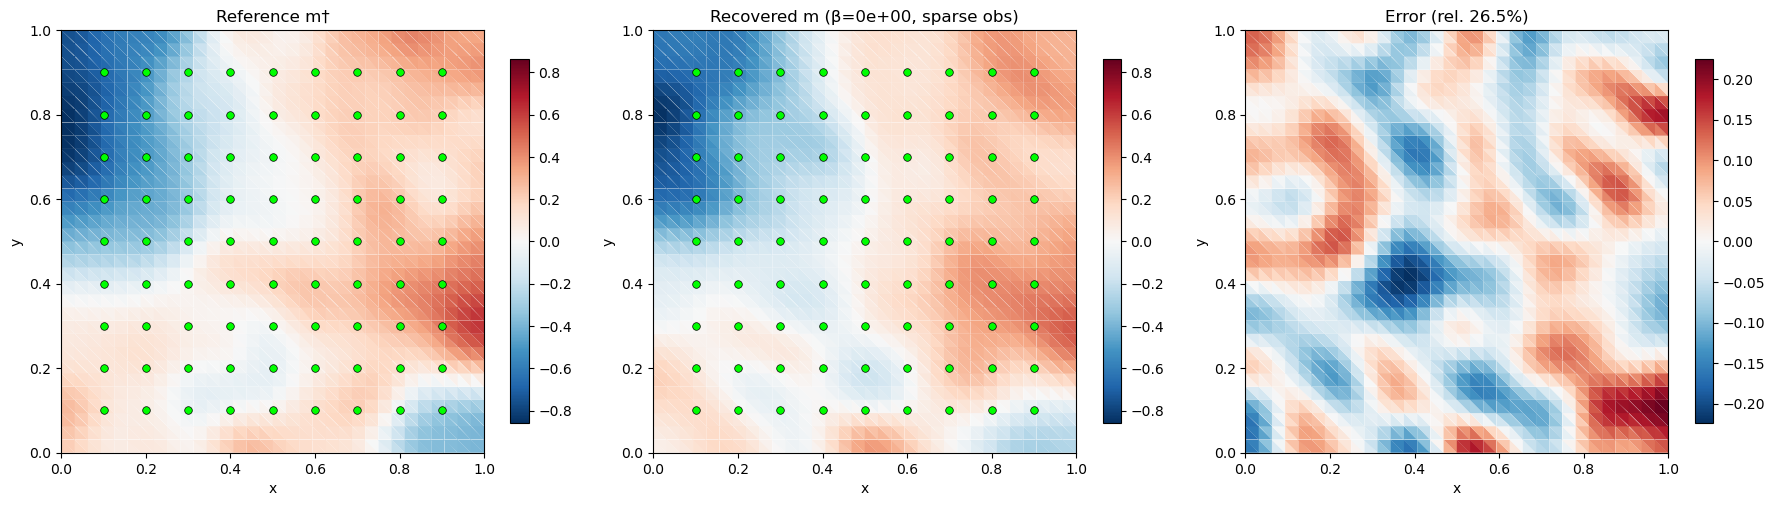

In [ ]:
# Compare true vs recovered permeability
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Determine common colorbar limits
vmin = min(np.min(m_true), np.min(m_rec))
vmax = max(np.max(m_true), np.max(m_rec))
vmax_abs = max(abs(vmin), abs(vmax))
vmin, vmax = -vmax_abs, vmax_abs

# True field
inv.plot_elementwise_field(m_true, ax=axes[0], vmin=vmin, vmax=vmax,
                           title='Reference m†')
axes[0].scatter(obs_points[:, 0], obs_points[:, 1], c='lime', s=30, marker='o',
                edgecolors='black', linewidths=0.5)

# Recovered field
inv.plot_elementwise_field(m_rec, ax=axes[1], vmin=vmin, vmax=vmax,
                           title=f'Recovered m (β={beta:.0e}, sparse obs)')
axes[1].scatter(obs_points[:, 0], obs_points[:, 1], c='lime', s=30, marker='o',
                edgecolors='black', linewidths=0.5)

# Error
error_m = m_rec - m_true
inv.plot_elementwise_field(error_m, ax=axes[2], 
                           title=f'Error (rel. {rel_error*100:.1f}%)')

plt.tight_layout()
#plt.savefig('figures/adjoint_reconstruction_sparse.png', dpi=150, bbox_inches='tight')
plt.show()

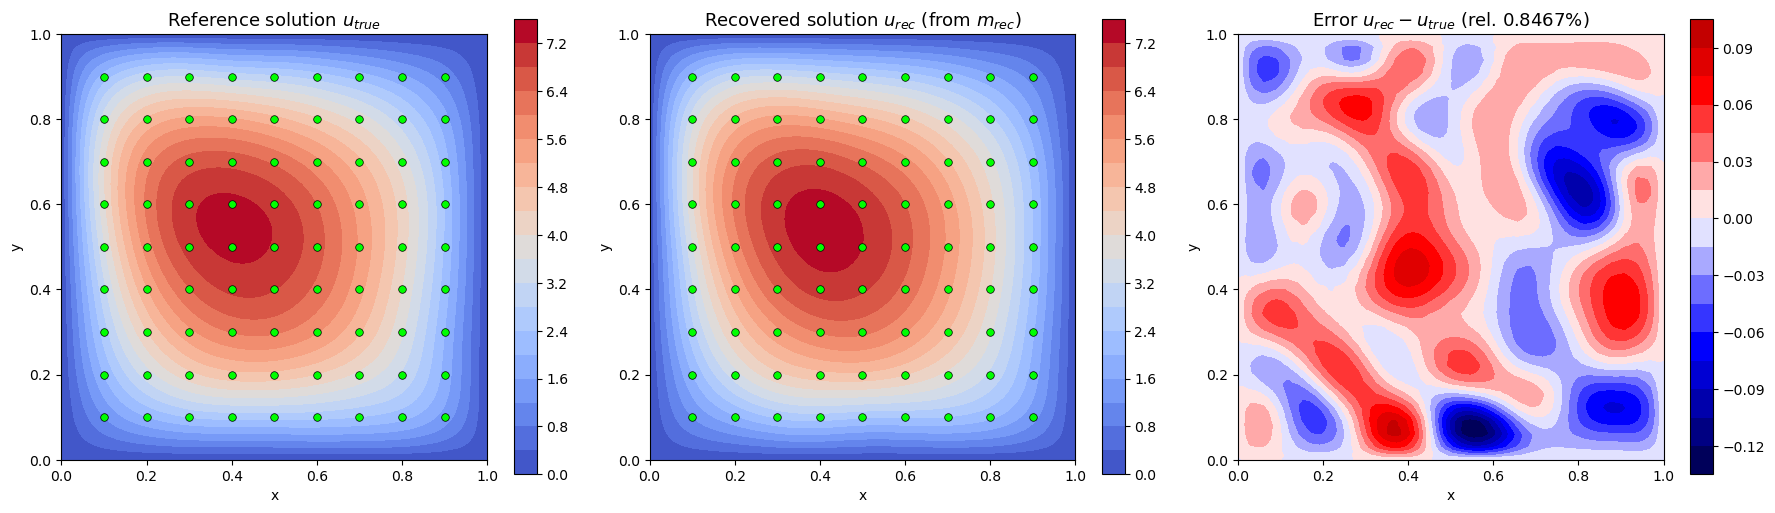


Solution recovery:
  ||u_rec - u_true||_2 / ||u_true||_2 = 0.8467%
  max|u_rec - u_true| = 1.3713e-01


In [ ]:
# Visualize the recovered solution u
from scipy.interpolate import griddata

# Solve forward problem with recovered m
u_rec = inv.solve_forward(m_rec)
u_error_rel = np.linalg.norm(u_rec - u_clean) / np.linalg.norm(u_clean)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Interpolate to regular grid for plotting
n_plot = 100
x_plot = np.linspace(0, 1, n_plot)
y_plot = np.linspace(0, 1, n_plot)
X_plot, Y_plot = np.meshgrid(x_plot, y_plot)

u_clean_grid = griddata(inv.nodes, u_clean, (X_plot, Y_plot), method='linear')
u_rec_grid = griddata(inv.nodes, u_rec, (X_plot, Y_plot), method='linear')
u_error_grid = u_rec_grid - u_clean_grid

# Common colorbar limits for u
vmin_u = min(np.nanmin(u_clean_grid), np.nanmin(u_rec_grid))
vmax_u = max(np.nanmax(u_clean_grid), np.nanmax(u_rec_grid))

# Clean solution
im0 = axes[0].contourf(X_plot, Y_plot, u_clean_grid, levels=20, cmap='coolwarm',
                        vmin=vmin_u, vmax=vmax_u)
axes[0].scatter(obs_points[:, 0], obs_points[:, 1], c='lime', s=30, marker='o',
                edgecolors='black', linewidths=0.5)
axes[0].set_title('Reference solution $u_{true}$', fontsize=13)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_aspect('equal')
plt.colorbar(im0, ax=axes[0])

# Recovered solution
im1 = axes[1].contourf(X_plot, Y_plot, u_rec_grid, levels=20, cmap='coolwarm',
                        vmin=vmin_u, vmax=vmax_u)
axes[1].scatter(obs_points[:, 0], obs_points[:, 1], c='lime', s=30, marker='o',
                edgecolors='black', linewidths=0.5)
axes[1].set_title(f'Recovered solution $u_{{rec}}$ (from $m_{{rec}}$)', fontsize=13)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_aspect('equal')
plt.colorbar(im1, ax=axes[1])

# Error
vmax_err = np.nanmax(np.abs(u_error_grid))
im2 = axes[2].contourf(X_plot, Y_plot, u_error_grid, levels=20, cmap='seismic',
                        vmin=-vmax_err, vmax=vmax_err)
axes[2].set_title(f'Error $u_{{rec}} - u_{{true}}$ (rel. {u_error_rel*100:.4f}%)', fontsize=13)
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].set_aspect('equal')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
#plt.savefig('figures/adjoint_solution_sparse.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSolution recovery:")
print(f"  ||u_rec - u_true||_2 / ||u_true||_2 = {u_error_rel*100:.4f}%")
print(f"  max|u_rec - u_true| = {np.max(np.abs(u_rec - u_clean)):.4e}")

## 7. Save the Adjoint Outputs

Persist the adjoint reconstruction, solver fields, and comparison bundles used by the later file-based plots.

In [46]:
# Save results to npz file
save_adjoint_results(
    inv,
    m_true=m_true,
    m_rec=m_rec,
    y_obs=y_obs,
    y_clean=y_clean,
    u_clean=u_clean,
    obs_points=obs_points,
    rel_error=rel_error,
    t_total=t_total,
    filepath='history/adjoint_results_sparse.npz',
    extra_data={
        'noise_level': NOISE_LEVEL,
        'noise_type': NOISE_TYPE,
    },
)

print(f"  Adjoint total time: {t_total:.2f}s")

# --- Save solver-based fields for the FILE-ONLY solution comparison (cell 35) ---
# Forward-solve here (inv is in scope) so the comparison plot needs no live solver.
u_true_solver = inv.solve_forward(m_true)
u_adj_solver = inv.solve_forward(m_rec)
np.savez(
    'history/solcmp_adjoint.npz',
    nodes=inv.nodes,            # FEM node coordinates (shared geometry)
    obs_points=obs_points,     # sparse observation locations
    m_true=m_true,             # true log-permeability on elements
    u_true_solver=u_true_solver,   # forward solve of true m at nodes
    m_adj_elem=m_rec,          # adjoint-recovered m on elements
    u_adj_solver=u_adj_solver, # forward solve of adjoint m at nodes
)
print('Adjoint solution bundle saved to history/solcmp_adjoint.npz')

Adjoint results saved to history/adjoint_results_sparse.npz
  Adjoint total time: 3.04s
Adjoint solution bundle saved to history/solcmp_adjoint.npz


## 8. Define the PINN Formulation

Set up the shared-trunk PINN that jointly predicts the state $u_\theta(x,y)$ and permeability field $m_\phi(x,y)$ from the same sparse noisy observations.

**Architecture:** $(x,y) \to \text{Trunk}(\text{shared}) \to \begin{cases} \text{Head}_u \to u \\ \text{Head}_m \to m \end{cases}$

**Total loss:**
$$\mathcal{L} = \mathcal{L}_{data} + \mathcal{L}_{pde} + \mathcal{L}_{bc} + \frac{\beta}{2}\mathcal{R}(m)$$

where:
- $\mathcal{L}_{data} = \frac{1}{N_{obs}}\sum_i |u_\theta(x_i,y_i) - y_i|^2$ at the 81 sparse observation points
- $\mathcal{L}_{pde} = \frac{1}{N_{pde}}\sum_j |{-\nabla\cdot(k\nabla u) - f}|^2$
- $\mathcal{L}_{bc} = \frac{1}{N_{bc}}\sum_b |u_\theta(x_b,y_b)|^2$
- $\mathcal{R}(m)$ combines the regularization terms used in the PINN loss

**Training schedule:** Adam warmup followed by SciPy BFGS with resampling and optional recovery steps.

In [47]:
# Import PINN solver (reload if already imported)
import importlib
import darcy_pinn
importlib.reload(darcy_pinn)
from darcy_pinn import DarcyPINN, plot_pinn_results, save_pinn_results
import torch

# Check device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


### 8.1 Configure PINN Hyperparameters

In [48]:
# ============================================================================
# PINN CONTROL VARIABLES
# ============================================================================

# Network architecture (shared trunk + two output heads)
hidden_dims = [32, 32, 32]    # Shared trunk layers
head_dims_u = []               # u output head (empty = single linear layer)
head_dims_m = [32]               # m output head (empty = single linear layer)

# Adam training parameters
n_adam_iters = 2000
adam_lr = 1e-3
adam_resample_every = 200  # Resample collocation points every N Adam steps

# BFGS training parameters (SSBroyden2 style from AllenCahn)
n_bfgs_epochs = 10         # Number of outer epochs (with resampling)
n_bfgs_restarts = 1        # Max BFGS restarts per epoch (with Adam recovery)
bfgs_maxiter = 200         # Max iterations per BFGS call
bfgs_method = 'SSBroyden2' # BFGS variant (requires patched scipy)
bfgs_gtol = 0.0            # Gradient tolerance
bfgs_ftol = 0.0            # Function tolerance
bfgs_target_loss = 10    # Stop if loss falls below this
adam_recovery_steps = 20   # Adam steps if BFGS fails
adam_recovery_lr = 1e-4    # Learning rate for Adam recovery
print_m_error_every = 50   # Print m error every N iterations in BFGS

# Collocation points
n_pde = 3000   # Interior points for PDE residual
n_bc = 200     # Boundary points for soft BC
n_reg = 1000   # Points for regularization

# ============================================================================
# REGULARIZATION - match the adjoint's misfit/reg WEIGHT RATIO
# ============================================================================
# Adjoint objective (GRF-coef space, sums over the mesh):
#   J = 0.5*sum_obs (u-y)^2  +  0.5*beta*sum_e m_e^2  +  0.5*gamma*sum_edges (m_i-m_j)^2/h_ij
# PINN loss (continuous functionals, MEAN over collocation points):
#   L = mean_obs (u-y)^2  +  L_pde + L_bc
#         +  0.5*beta_pinn*mean(m^2)  +  0.5*gamma_pinn*mean(|grad m|^2)
#
# The two normalize differently (adjoint = sum, PINN = mean), so reusing gamma
# verbatim would give the H1 term a different effective strength. We instead match
# the ratio (reg weight)/(data weight):
#   data term:  adjoint coef on sum_obs(u-y)^2 = 0.5;   PINN coef = 1/N_obs
#   H1 term:    adjoint graph seminorm sum_edges(m_i-m_j)^2/h ~= C_mesh * int|grad m|^2
#               PINN term mean(|grad m|^2)               ~= int|grad m|^2
#   => gamma_pinn = 2 * gamma * C_mesh / N_obs      (and beta_pinn = beta)
# C_mesh (~O(1/h), mesh-dependent) is measured numerically on the true field below.

N_obs = len(obs_points)

# Adjoint graph-H1 seminorm of the true (piecewise-constant) field
graph_h1_true = sum((m_true[e_i] - m_true[e_j])**2 / h_ij
                    for e_i, e_j, h_ij in inv.element_neighbors)

# Continuous int|grad m_true|^2 of the SMOOTH GRF field (fine-grid finite differences)
_ng = 200
_grid = np.linspace(0, 1, _ng)
_X, _Y = np.meshgrid(_grid, _grid)
_m_smooth = RF.sample(np.column_stack([_X.ravel(), _Y.ravel()]), coefs).reshape(_ng, _ng)
_dm_dy, _dm_dx = np.gradient(_m_smooth, _grid, _grid)
int_grad_sq_true = np.mean(_dm_dx**2 + _dm_dy**2)   # int over unit square ~= mean

C_mesh = graph_h1_true / int_grad_sq_true

pinn_beta = beta                                 # L2 weight unchanged (beta = 0 here)
pinn_gamma = 2.0 * gamma * C_mesh / N_obs         # rescaled H1 weight

print("Regularization rescaling (PINN <-> adjoint):")
print(f"  N_obs = {N_obs}")
print(f"  adjoint graph-H1 |m_true|   = {graph_h1_true:.4e}")
print(f"  continuous int|grad m_true|^2 = {int_grad_sq_true:.4e}")
print(f"  C_mesh = graph_H1 / int|grad m|^2 = {C_mesh:.4f}")
print(f"  gamma (adjoint) = {gamma:.2e}  ->  gamma_pinn = {pinn_gamma:.4e}")
print(f"  beta  (adjoint) = {beta:.2e}  ->  beta_pinn  = {pinn_beta:.2e}")

print("\nPINN configuration:")
print(f"  Shared trunk: {hidden_dims}, u head: {head_dims_u or '[linear]'}, m head: {head_dims_m or '[linear]'}")
print(f"  Adam: {n_adam_iters} iters, lr={adam_lr}, resample every {adam_resample_every}")
print(f"  BFGS: {n_bfgs_epochs} epochs x {n_bfgs_restarts} restarts x {bfgs_maxiter} iters")
print(f"  BFGS method: {bfgs_method}, gtol={bfgs_gtol}, ftol={bfgs_ftol}")
print(f"  Print m error every: {print_m_error_every} BFGS iterations")
print(f"  Collocation: {n_pde} PDE, {n_bc} BC, {n_reg} reg")
print(f"  Observation points: {len(obs_points)} sparse")
print(f"  Regularization: beta = {pinn_beta:.2e} (L2), gamma = {pinn_gamma:.2e} (H1)")

Regularization rescaling (PINN <-> adjoint):
  N_obs = 81
  adjoint graph-H1 |m_true|   = 7.6545e+01
  continuous int|grad m_true|^2 = 3.5613e+00
  C_mesh = graph_H1 / int|grad m|^2 = 21.4936
  gamma (adjoint) = 1.00e-03  ->  gamma_pinn = 5.3071e-04
  beta  (adjoint) = 0.00e+00  ->  beta_pinn  = 0.00e+00

PINN configuration:
  Shared trunk: [32, 32, 32], u head: [linear], m head: [32]
  Adam: 2000 iters, lr=0.001, resample every 200
  BFGS: 10 epochs x 1 restarts x 200 iters
  BFGS method: SSBroyden2, gtol=0.0, ftol=0.0
  Print m error every: 50 BFGS iterations
  Collocation: 3000 PDE, 200 BC, 1000 reg
  Observation points: 81 sparse
  Regularization: beta = 0.00e+00 (L2), gamma = 5.31e-04 (H1)


### 8.2 Create and Train the PINN

In [49]:

# Define forcing function for PyTorch (must match f_given used by adjoint/EnKF)
def f_torch(x, y):
    """Source term f(x,y) = 100 (constant), matching adjoint & EnKF."""
    return 100.0 * torch.ones_like(x)

# Define true m function for error tracking using the same GRF as adjoint/EnKF
def m_true_func(x, y):
    """True m(x,y) via GRF evaluation — consistent with adjoint & EnKF."""
    x_flat = np.asarray(x).flatten()
    y_flat = np.asarray(y).flatten()
    pts = np.column_stack([x_flat, y_flat])
    return RF.sample(pts, coefs).flatten().reshape(np.asarray(x).shape)

# Create PINN solver using SPARSE observation data (NOISY)
pinn = DarcyPINN(
    f_func=f_torch,
    data_points=obs_points,     # Sparse observation coordinates (9×9 grid)
    data_values=y_obs,          # Observed u values at sparse points (NOISY)
    beta=pinn_beta,
    gamma=pinn_gamma,
    hidden_dims=hidden_dims,
    head_dims_u=head_dims_u,
    head_dims_m=head_dims_m,
    device=device,
    m_true_func=m_true_func     # GRF-based for error tracking during training
)

print(f"PINN created (shared-trunk architecture):")
print(f"  Data points: {pinn.n_data} (sparse observations)")
print(f"  Data is NOISY ({NOISE_LEVEL*100:.0f}% of max|u|)")
print(f"  f(x,y) = 100 (constant, matching adjoint/EnKF)")
print(f"  m_true from GRF (matching adjoint/EnKF)")
print(f"  Total network params: {sum(p.numel() for p in pinn.net.parameters())}")


PINN created (shared-trunk architecture):
  Data points: 81 (sparse observations)
  Data is NOISY (1% of max|u|)
  f(x,y) = 100 (constant, matching adjoint/EnKF)
  m_true from GRF (matching adjoint/EnKF)
  Total network params: 3330


In [50]:
# Train with Adam
t_start = time.time()

pinn.train_adam(
    n_iterations=n_adam_iters,
    lr=adam_lr,
    resample_every=adam_resample_every,
    n_pde=n_pde,
    n_bc=n_bc,
    n_reg=n_reg,
    verbose=True,
    print_every=500
)

t_adam = time.time() - t_start
print(f"\nAdam phase completed in {t_adam:.2f}s")

PINN Training - Adam Phase
  Iterations: 2000
  Learning rate: 0.001
  Resample every: 200 iterations
  Collocation points: 3000 PDE, 200 BC, 1000 reg
  Observation points: 81
----------------------------------------------------------------------
  Iter   500: loss=1.5695e+01, data=1.0274e+01, pde=2.4240e+00, bc=2.9968e+00, |∇|=2.7633e+01, m_err=1346.07%
  Iter  1000: loss=1.3267e+01, data=8.1647e+00, pde=8.6873e-01, bc=4.2332e+00, |∇|=9.1696e+00, m_err=1389.13%
  Iter  1500: loss=1.2487e+01, data=7.4908e+00, pde=3.7499e-01, bc=4.6214e+00, |∇|=4.7176e+00, m_err=1441.13%
  Iter  2000: loss=1.3055e+01, data=7.4426e+00, pde=7.8600e-01, bc=4.8261e+00, |∇|=1.0200e+03, m_err=1496.35%
----------------------------------------------------------------------
  Adam training completed in 17.10s

Adam phase completed in 17.10s


In [51]:
# Fine-tune with BFGS (SSBroyden2 with epochs, restarts, and Adam recovery)
# Now prints m error every 50 iterations
t_start = time.time()

pinn.train_bfgs(
    maxiter=bfgs_maxiter,
    n_epochs=n_bfgs_epochs,
    n_restarts=n_bfgs_restarts,
    resample_every_epoch=True,
    n_pde=n_pde,
    n_bc=n_bc,
    n_reg=n_reg,
    method_bfgs=bfgs_method,
    gtol=bfgs_gtol,
    ftol=bfgs_ftol,
    target_loss=bfgs_target_loss,
    adam_recovery_steps=adam_recovery_steps,
    adam_recovery_lr=adam_recovery_lr,
    verbose=True,
    disp=False,
    print_m_error_every=print_m_error_every  # Print m error every 50 iterations
)

t_bfgs = time.time() - t_start
print(f"\nBFGS phase completed in {t_bfgs:.2f}s")
print(f"Total PINN training time: {t_adam + t_bfgs:.2f}s")

PINN Training - BFGS Phase (SSBroyden2)
  Epochs: 10, Max restarts/epoch: 1
  Max iter/restart: 200, method_bfgs: SSBroyden2
  gtol: 0.00e+00, ftol: 0.00e+00, target_loss: 1.00e+01
  Resample each epoch: True
  Print m error every: 50 iterations
----------------------------------------------------------------------

  Epoch 1/10
  [BFGS iter   50] loss=1.1862e+01, data=7.2675e+00, pde=3.4356e-02, bc=4.5601e+00, reg=5.1694e-05, |∇|=1.0758e+01, m_err=1762.2420%
  [BFGS iter  100] loss=1.1378e+01, data=7.5303e+00, pde=3.1423e-01, bc=3.5336e+00, reg=1.4988e-04, |∇|=9.1779e+01, m_err=1189.0022%
  [BFGS iter  150] loss=9.2825e+00, data=5.6270e+00, pde=4.6575e-01, bc=3.1896e+00, reg=1.7927e-04, |∇|=1.7514e+02, m_err=640.4140%
  [BFGS iter  200] loss=4.6371e+00, data=1.0505e+00, pde=1.8488e+00, bc=1.7378e+00, reg=9.1449e-05, |∇|=1.1718e+02, m_err=214.3858%
  [BFGS iter  250] loss=1.4435e+00, data=1.8857e-01, pde=1.8860e-01, bc=1.0660e+00, reg=3.0311e-04, |∇|=2.6721e+02, m_err=119.4403%
    Res

### 8.3 Visualize and Save the PINN Outputs

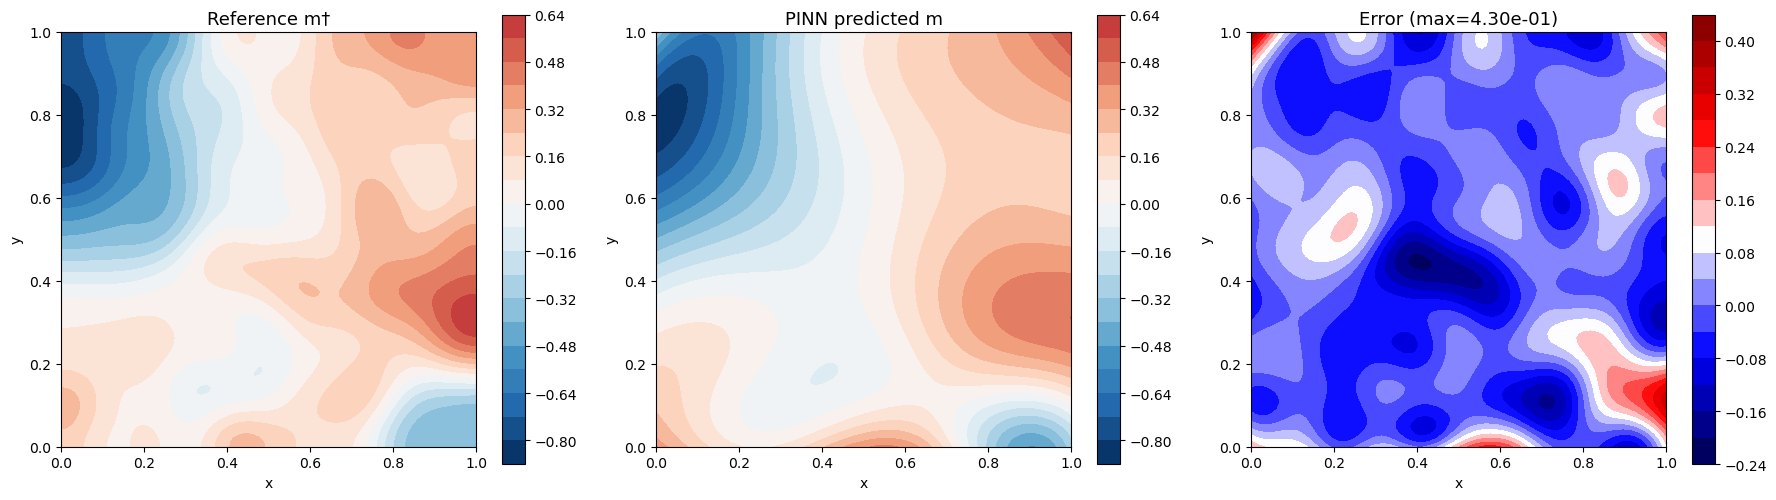

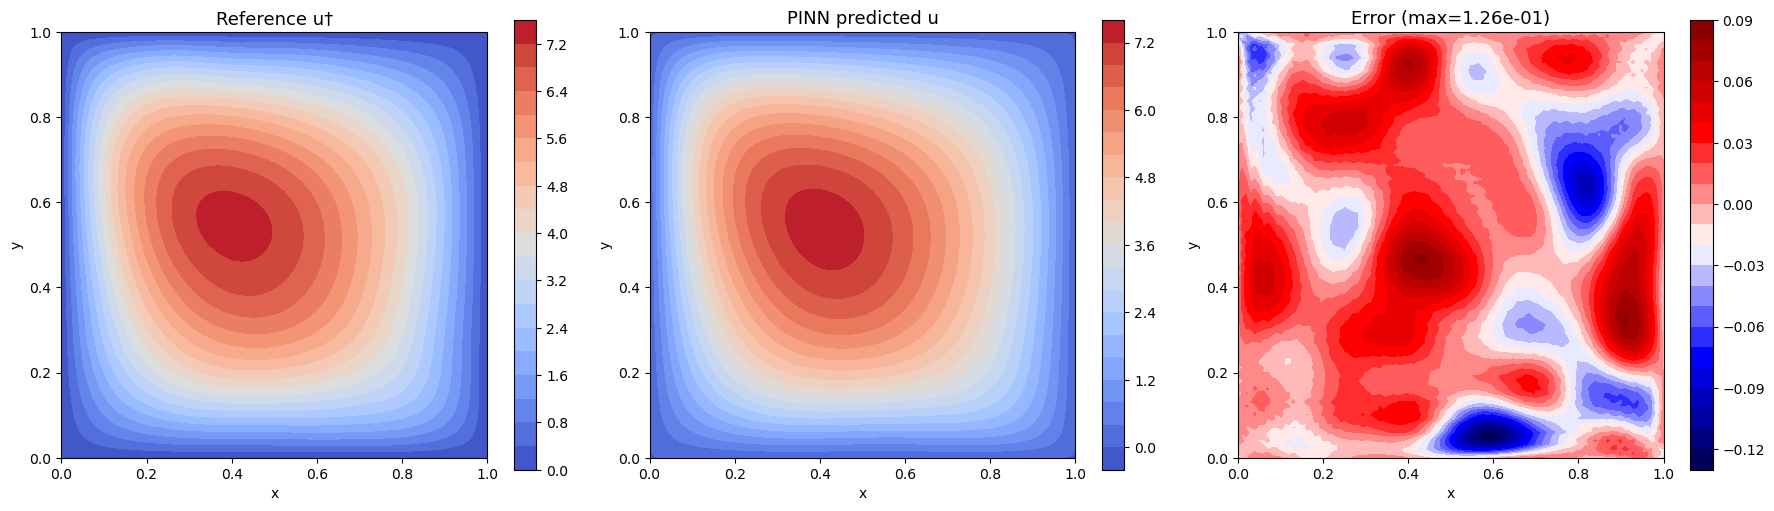

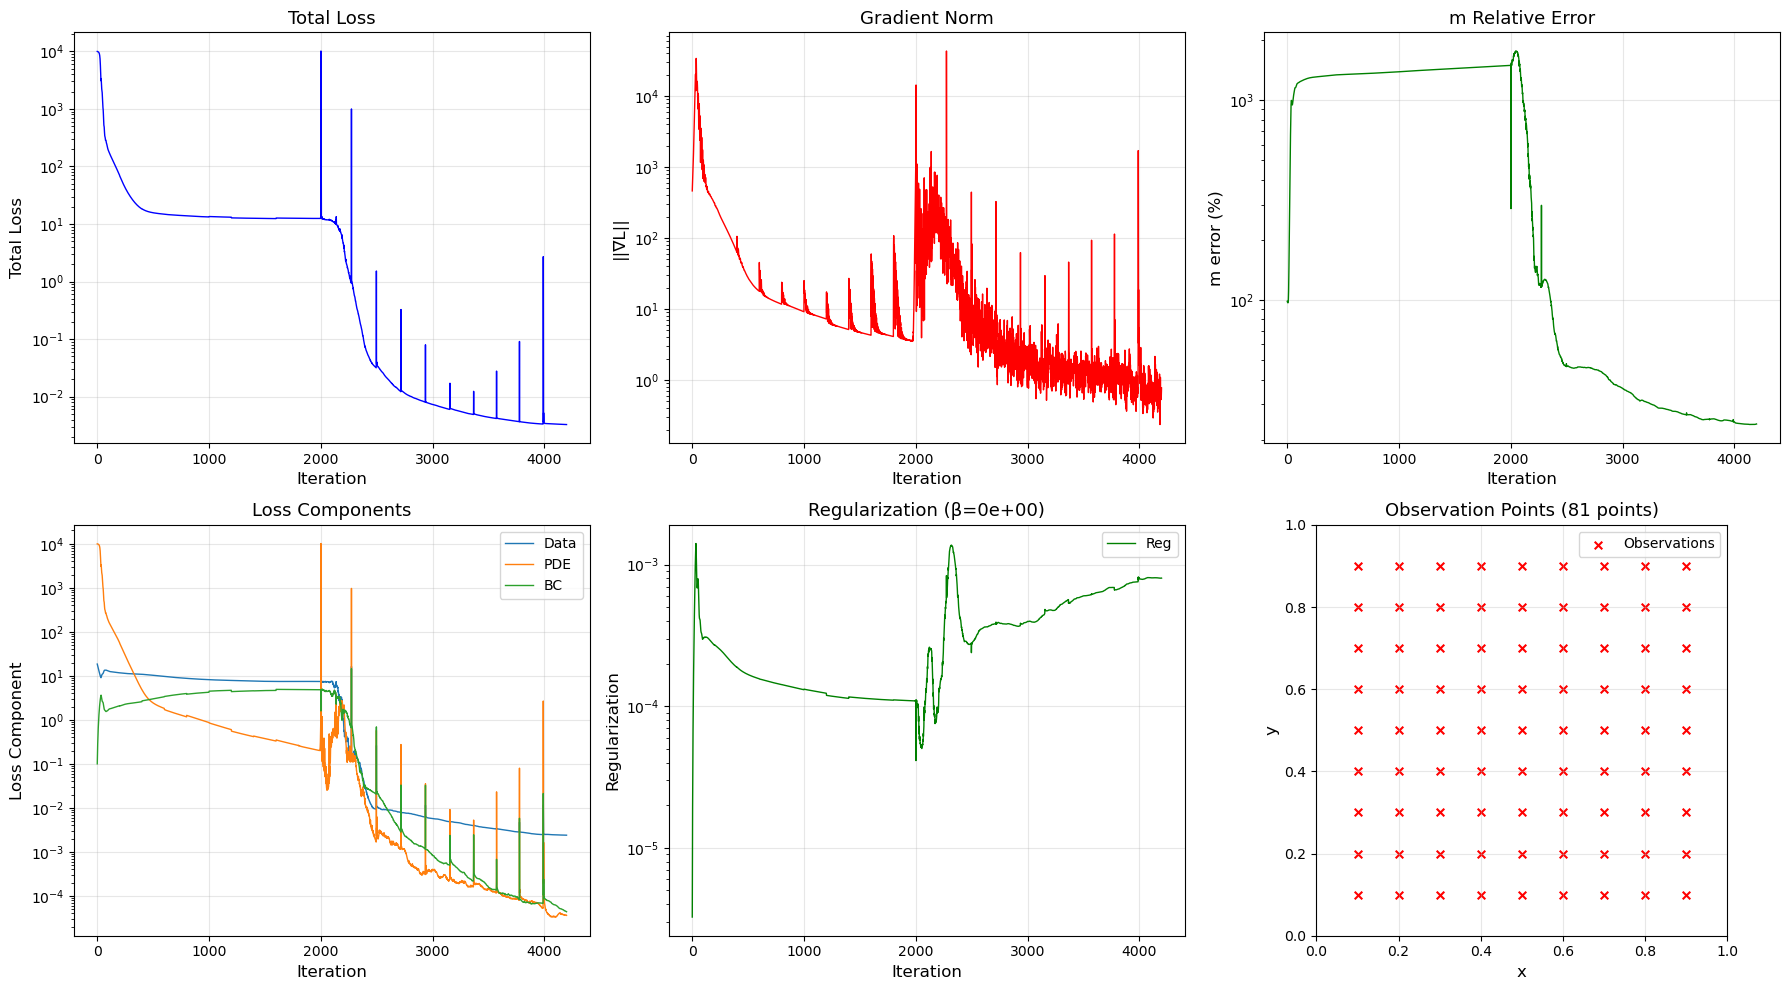


PINN Reconstruction Errors:
  Relative m error: 23.65%
  Relative u error: 0.7940%


In [52]:
# Plot PINN results and compare with reference
pinn_rel_error_m, pinn_rel_error_u = plot_pinn_results(
    pinn,
    m_true_func=m_true_func,
    u_true=u_clean,  # Compare against clean solution
    nodes=inv.nodes,
    save_prefix='figures/pinn_sparse'
)

In [60]:
# Save PINN results
save_pinn_results(
    pinn,
    m_true_func=m_true_func,
    u_true=u_clean,
    nodes=inv.nodes,
    filepath='history/pinn_results_sparse.npz',
    extra_data={
        't_adam': t_adam,
        't_bfgs': t_bfgs,
        't_total': t_adam + t_bfgs,
        'n_adam_iters': n_adam_iters,
        'noise_level': NOISE_LEVEL,
        'noise_type': NOISE_TYPE
    }
)

# Save model weights
torch.save({
    'net_state_dict': pinn.net.state_dict(),
    'hidden_dims': hidden_dims,
    'head_dims_u': head_dims_u,
    'head_dims_m': head_dims_m,
    'beta': pinn_beta,
    't_adam': t_adam,
    't_bfgs': t_bfgs,
    't_total': t_adam + t_bfgs,
    'n_adam_iters': n_adam_iters,
    'noise_level': NOISE_LEVEL,
    'noise_type': NOISE_TYPE,
    'obs_points': obs_points
}, 'history/pinn_model_sparse.pt')

print("Model saved to history/pinn_model_sparse.pt")
print(f"  PINN Adam time: {t_adam:.2f}s")
print(f"  PINN BFGS time: {t_bfgs:.2f}s")
print(f"  PINN total time: {t_adam + t_bfgs:.2f}s")

# --- Save solver-based PINN fields for the FILE-ONLY solution comparison (cell 35) ---
m_pinn_elem = pinn.predict_m(inv.element_centroids[:, 0], inv.element_centroids[:, 1])
u_pinn_solver = inv.solve_forward(m_pinn_elem)
np.savez(
    'history/solcmp_pinn.npz',
    m_pinn_elem=m_pinn_elem,        # PINN m sampled on FEM elements
    u_pinn_solver=u_pinn_solver,    # forward solve of PINN m at nodes
)
print('PINN solution bundle saved to history/solcmp_pinn.npz')

PINN results saved to history/pinn_results_sparse.npz
Model saved to history/pinn_model_sparse.pt
  PINN Adam time: 17.10s
  PINN BFGS time: 168.63s
  PINN total time: 185.73s
PINN solution bundle saved to history/solcmp_pinn.npz


## 9. Run Ensemble Kalman Inversion

Recover the GRF coefficients $\xi \in \mathbb{R}^{128}$ with EKI using the same observation operator, GRF prior, and noise model as the adjoint and PINN methods.

In [53]:
# EKI setup — same problem as adjoint and PINN
J = 2000                 # Ensemble size
dim = coefs.shape[0]     # GRF coefficient dimension (128)
np.random.seed(42)
initial_ensemble = np.random.randn(J, dim)

# Observation noise covariance (same noise model)
noise_std_eki = NOISE_LEVEL * np.max(np.abs(y_clean))
R_eki = noise_std_eki**2 * np.eye(len(y_obs))

eki_solver = EKI(J, dim, len(y_obs))
n_eki_iterations = 5

# Forward model: GRF coefficients → observed pressure
def forward_eki(coef):
    m = RF.sample(kappa_mesh, coef).flatten()
    return inv.observe(inv.solve_forward(m))

t_eki_start = time.time()
final_ensemble = eki_solver.run(initial_ensemble, y_obs, forward_eki, R_eki, n_eki_iterations)
t_eki = time.time() - t_eki_start
print(f"\nEKI completed in {t_eki:.2f}s")

100%|██████████| 2000/2000 [00:29<00:00, 68.45it/s]


Iteration 1/5, Misfit: 64.6114%%


100%|██████████| 2000/2000 [00:29<00:00, 68.64it/s]


Iteration 2/5, Misfit: 37.4428%%


100%|██████████| 2000/2000 [00:29<00:00, 68.53it/s]


Iteration 3/5, Misfit: 33.0316%%


100%|██████████| 2000/2000 [00:29<00:00, 68.47it/s]


Iteration 4/5, Misfit: 30.1649%%


100%|██████████| 2000/2000 [00:29<00:00, 68.41it/s]

Iteration 5/5, Misfit: 28.0467%%

EKI completed in 146.10s


In [54]:
# EKI: Compute ensemble mean prediction
m_eki_mean = RF.sample(kappa_mesh, final_ensemble).mean(axis=0)
u_eki = inv.solve_forward(m_eki_mean)

# Compute EKI errors
eki_m_error = np.linalg.norm(m_eki_mean - m_true) / np.linalg.norm(m_true)
eki_u_error = np.linalg.norm(u_eki - u_clean) / np.linalg.norm(u_clean)
print(f"EKI m relative error: {eki_m_error*100:.2f}%")
print(f"EKI u relative error: {eki_u_error*100:.4f}%")

EKI m relative error: 22.35%
EKI u relative error: 0.7554%


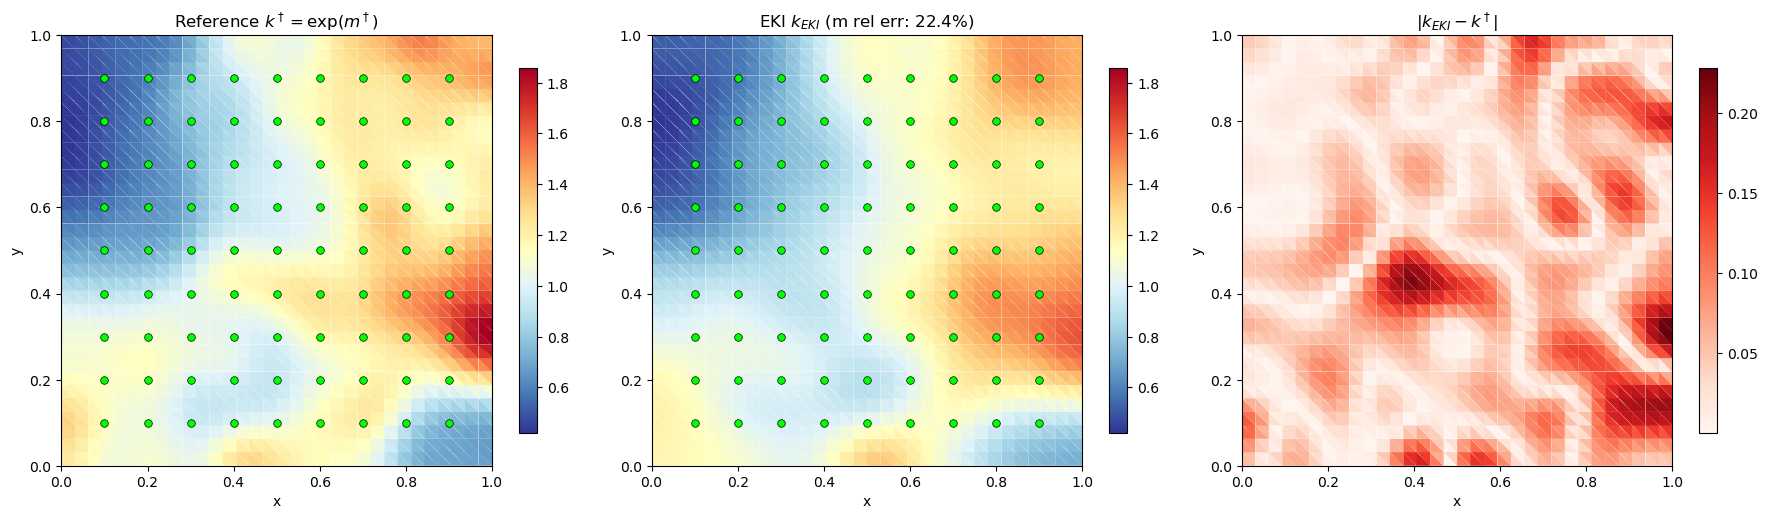

In [ ]:
# Visualize EKI results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

vmin_k = min(np.min(np.exp(m_true)), np.min(np.exp(m_eki_mean)))
vmax_k = max(np.max(np.exp(m_true)), np.max(np.exp(m_eki_mean)))

# True k = exp(m)
inv.plot_elementwise_field(np.exp(m_true), ax=axes[0], cmap='RdYlBu_r',
                           title='Reference $k^\\dagger = \\exp(m^\\dagger)$',
                           vmin=vmin_k, vmax=vmax_k)
axes[0].scatter(obs_points[:, 0], obs_points[:, 1], c='lime', s=30, marker='o',
                edgecolors='black', linewidths=0.5)

# EKI recovered k
inv.plot_elementwise_field(np.exp(m_eki_mean), ax=axes[1], cmap='RdYlBu_r',
                           title=f'EKI $k_{{EKI}}$ (m rel err: {eki_m_error*100:.1f}%)',
                           vmin=vmin_k, vmax=vmax_k)
axes[1].scatter(obs_points[:, 0], obs_points[:, 1], c='lime', s=30, marker='o',
                edgecolors='black', linewidths=0.5)

# Absolute error
inv.plot_elementwise_field(np.abs(np.exp(m_eki_mean) - np.exp(m_true)), ax=axes[2],
                           cmap='Reds', title='|$k_{EKI} - k^\\dagger$|')

plt.tight_layout()
#plt.savefig('figures/eki_reconstruction.png', dpi=150, bbox_inches='tight')
plt.show()

In [56]:
# Save EKI results (solver-based fields for the FILE-ONLY comparison in cell 35)
u_eki_solver = inv.solve_forward(m_eki_mean)
np.savez(
    'history/solcmp_eki.npz',
    m_eki_elem=m_eki_mean,          # EKI ensemble-mean m on elements
    u_eki_solver=u_eki_solver,      # forward solve of EKI m at nodes
    final_ensemble=final_ensemble,  # full final ensemble (GRF coefficients)
    eki_m_error=eki_m_error,
    eki_u_error=eki_u_error,
    t_eki=t_eki,
)
print('EKI solution bundle saved to history/solcmp_eki.npz')
print(f'  EKI m rel error: {eki_m_error*100:.2f}%,  u rel error: {eki_u_error*100:.4f}%')

EKI solution bundle saved to history/solcmp_eki.npz
  EKI m rel error: 22.35%,  u rel error: 0.7554%


## 10. Compare the Three Reconstructions

Compare the recovered permeability fields and the solver-based state reconstructions from the adjoint, PINN, and EKI pipelines.

### 10.1 Compare Permeability Fields and Grid-Based Errors

/tmp/ipykernel_70142/2119641485.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])


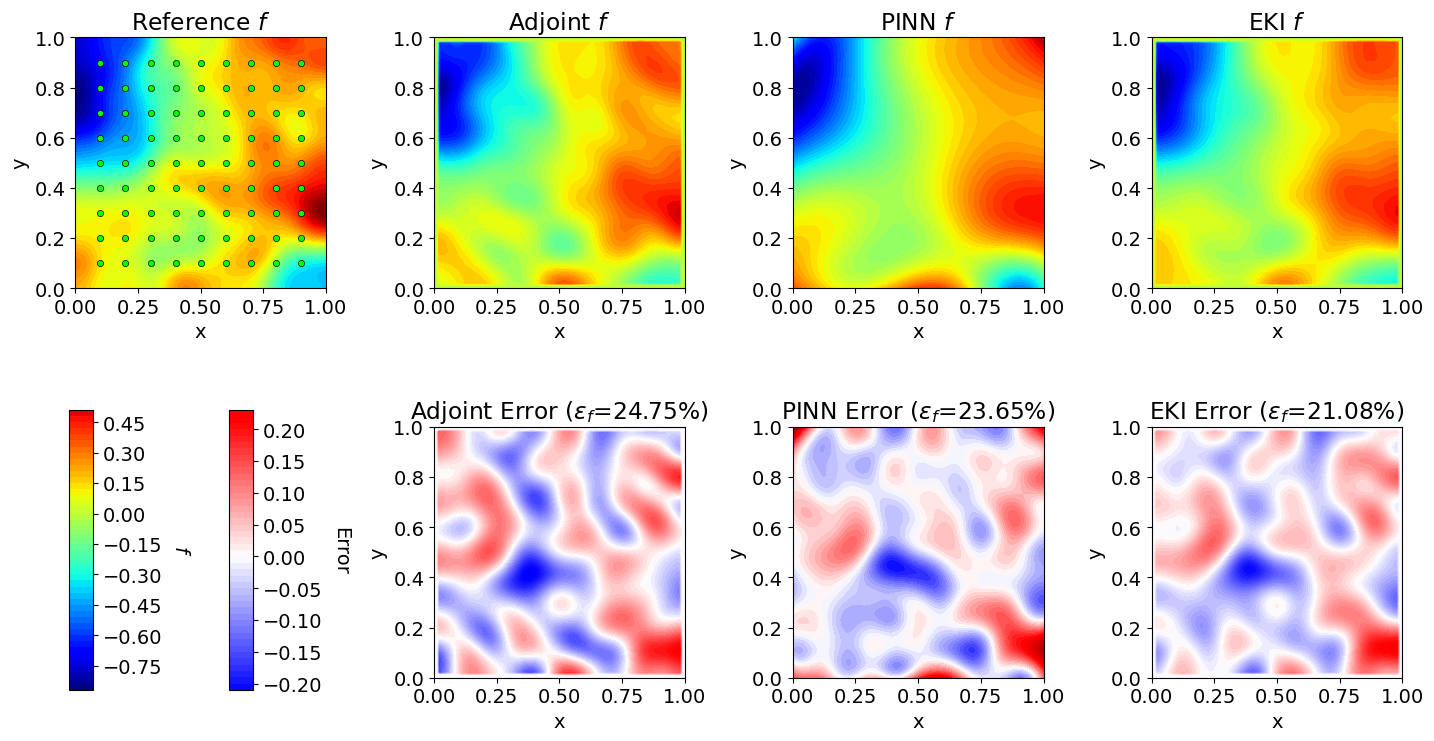


COMPARISON: Adjoint vs PINN vs EKI (Sparse Observations, 1% Noise)
Method             m rel. error    u rel. error
---------------------------------------------
Adjoint                  26.54%         0.8467%
PINN                     23.65%         0.7940%
EKI                      22.35%         0.7554%


In [61]:
# Side-by-side comparison: Adjoint vs PINN vs EKI
from scipy.interpolate import griddata

n_plot = 100
x_plot = np.linspace(0, 1, n_plot)
y_plot = np.linspace(0, 1, n_plot)
X_plot, Y_plot = np.meshgrid(x_plot, y_plot)
X_flat, Y_flat = X_plot.flatten(), Y_plot.flatten()

# True field on grid (displayed as f)
f_true_grid = m_true_func(X_plot, Y_plot)

# PINN prediction on grid
f_pinn_grid = pinn.predict_m(X_flat, Y_flat).reshape(n_plot, n_plot)

# Adjoint: interpolate elementwise field to grid
elem_centroids = inv.element_centroids
f_adj_grid = griddata(elem_centroids, m_rec, (X_plot, Y_plot), method='linear')

# EKI: interpolate elementwise field to grid
f_eki_grid = griddata(elem_centroids, m_eki_mean, (X_plot, Y_plot), method='linear')

# Compute errors
error_adj = f_adj_grid - f_true_grid
error_pinn = f_pinn_grid - f_true_grid
error_eki = f_eki_grid - f_true_grid

# Relative L2 errors (computing only on valid data for fields with NaN)
rel_err_adj_grid = np.linalg.norm(np.nan_to_num(error_adj)) / np.linalg.norm(f_true_grid)
rel_err_pinn_grid = np.linalg.norm(error_pinn) / np.linalg.norm(f_true_grid)
rel_err_eki_grid = np.linalg.norm(np.nan_to_num(error_eki)) / np.linalg.norm(f_true_grid)

# Fill NaN values in error fields for visualization (use 0 for NaN regions)
error_adj = np.nan_to_num(error_adj, nan=0.0)
error_eki = np.nan_to_num(error_eki, nan=0.0)

with plt.rc_context({'font.size': 14}):
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    vmax = max(f_true_grid.max(), f_pinn_grid.max(),
               np.nan_to_num(f_adj_grid).max(), np.nan_to_num(f_eki_grid).max())
    vmin = min(f_true_grid.min(), f_pinn_grid.min(),
               np.nan_to_num(f_adj_grid).min(), np.nan_to_num(f_eki_grid).min())

    # Row 1: f fields (use jet colormap)
    ims_f = []
    is_plot = False
    for ax, data, title in zip(
        axes[0],
        [f_true_grid, f_adj_grid, f_pinn_grid, f_eki_grid],
        ['Reference $f$',
         'Adjoint $f$',
         'PINN $f$',
         'EKI $f$']):
        im = ax.contourf(X_plot, Y_plot, np.nan_to_num(data), levels=50, cmap='jet',
                         vmin=vmin, vmax=vmax)
        ims_f.append(im)
        if not is_plot:
            ax.scatter(obs_points[:, 0], obs_points[:, 1], c='lime', s=20, marker='o',
                       edgecolors='black', linewidths=0.5)
            is_plot = True
        ax.set_title(title)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_aspect('equal')

    # Shared colorbar for f fields (right side)
    cbar_f_ax = fig.add_axes([0.05, 0.1, 0.015, 0.35])
    cbar_f = fig.colorbar(ims_f[-1], cax=cbar_f_ax, orientation='vertical')
    cbar_f.set_label('$f$', rotation=270, labelpad=20)

    # Row 2: Errors
    vmax_err = max(np.abs(error_adj).max(), np.abs(error_pinn).max(), np.abs(error_eki).max())

    axes[1, 0].axis('off')

    ims_err = []
    for ax, err, label, rel_err in zip(
        axes[1, 1:],
        [error_adj, error_pinn, error_eki],
        ['Adjoint', 'PINN', 'EKI'],
        [rel_err_adj_grid, rel_err_pinn_grid, rel_err_eki_grid]):
        im = ax.contourf(X_plot, Y_plot, err, levels=50, cmap='seismic',
                         vmin=-vmax_err, vmax=vmax_err)
        ims_err.append(im)
        ax.set_title(rf'{label} Error ($\varepsilon_f$={rel_err*100:.2f}%)')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_aspect('equal')

    # Shared colorbar for errors (right side)
    cbar_err_ax = fig.add_axes([0.15, 0.1, 0.015, 0.35])
    cbar_err = fig.colorbar(ims_err[-1], cax=cbar_err_ax, orientation='vertical')
    cbar_err.set_label('Error', rotation=270, labelpad=20)

    plt.tight_layout(rect=[0, 0, 0.91, 1])
    plt.savefig('figures/three_method_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

# Summary comparison table
u_rec = inv.solve_forward(m_rec)
print("\n" + "="*70)
print("COMPARISON: Adjoint vs PINN vs EKI (Sparse Observations, 1% Noise)")
print("="*70)
print(f"{'Method':<15} {'m rel. error':>15} {'u rel. error':>15}")
print("-"*45)
print(f"{'Adjoint':<15} {rel_error*100:>14.2f}% {np.linalg.norm(u_rec - u_clean)/np.linalg.norm(u_clean)*100:>14.4f}%")
print(f"{'PINN':<15} {pinn_rel_error_m*100:>14.2f}% {pinn_rel_error_u*100:>14.4f}%")
print(f"{'EKI':<15} {eki_m_error*100:>14.2f}% {eki_u_error*100:>14.4f}%")
print("="*70)


### 10.2 Compare Solver-Based State Reconstructions

Use the saved solver bundles to compare the recovered pressure fields without depending on live notebook state.

/tmp/ipykernel_70142/3981882750.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])


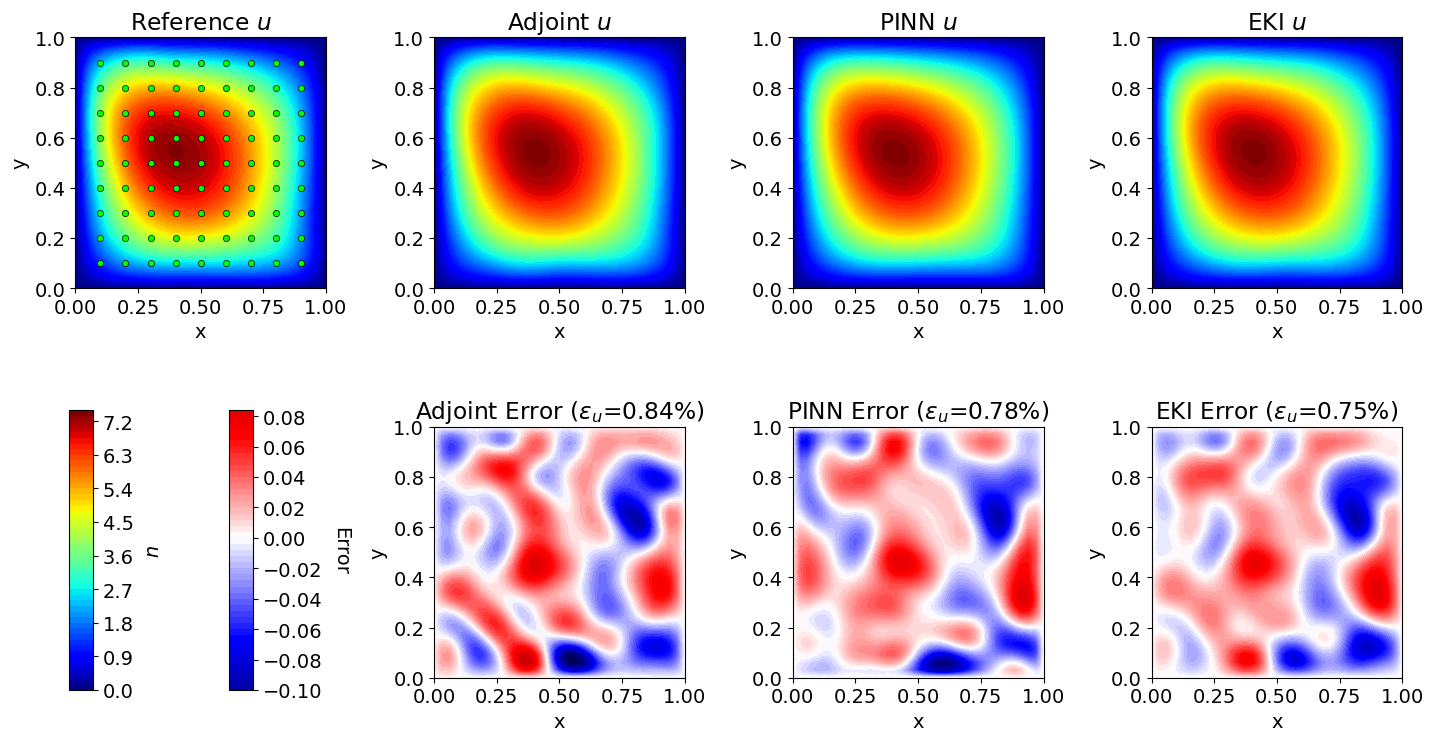

Solver-based solution relative L2 errors (from saved files):
  Adjoint: 0.8383%
  PINN->solver: 0.7828%
  EKI->solver: 0.7498%


In [62]:
# Side-by-side comparison of solution u from solver -- FILE-ONLY.
# This plot is independent of the live run: it reads pre-saved solver fields from
#   history/solcmp_adjoint.npz, history/solcmp_pinn.npz, history/solcmp_eki.npz
# (each method's m was forward-solved with inv.solve_forward at save time).
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

d_adj = np.load('history/solcmp_adjoint.npz')
d_pinn = np.load('history/solcmp_pinn.npz')
d_eki = np.load('history/solcmp_eki.npz')

# Shared geometry + true field (stored once, in the adjoint bundle)
nodes = d_adj['nodes']
obs_points = d_adj['obs_points']
u_true_solver = d_adj['u_true_solver']

# Solver-based u fields for each method (already forward-solved at save time)
u_adj_solver = d_adj['u_adj_solver']
u_pinn_solver = d_pinn['u_pinn_solver']
u_eki_solver = d_eki['u_eki_solver']

# Interpolate to regular grid for visualization
n_plot_u = 100
x_plot_u = np.linspace(0, 1, n_plot_u)
y_plot_u = np.linspace(0, 1, n_plot_u)
X_plot_u, Y_plot_u = np.meshgrid(x_plot_u, y_plot_u)

u_true_grid = griddata(nodes, u_true_solver, (X_plot_u, Y_plot_u), method='linear')
u_adj_grid = griddata(nodes, u_adj_solver, (X_plot_u, Y_plot_u), method='linear')
u_pinn_grid = griddata(nodes, u_pinn_solver, (X_plot_u, Y_plot_u), method='linear')
u_eki_grid = griddata(nodes, u_eki_solver, (X_plot_u, Y_plot_u), method='linear')

# Compute errors
err_adj_u = u_adj_grid - u_true_grid
err_pinn_u = u_pinn_grid - u_true_grid
err_eki_u = u_eki_grid - u_true_grid

# Relative L2 errors (using nan_to_num to handle any NaN values)
rel_u_adj = np.linalg.norm(np.nan_to_num(err_adj_u)) / np.linalg.norm(u_true_grid)
rel_u_pinn = np.linalg.norm(err_pinn_u) / np.linalg.norm(u_true_grid)
rel_u_eki = np.linalg.norm(np.nan_to_num(err_eki_u)) / np.linalg.norm(u_true_grid)

# Fill NaN values in error fields for visualization
err_adj_u = np.nan_to_num(err_adj_u, nan=0.0)
err_eki_u = np.nan_to_num(err_eki_u, nan=0.0)

with plt.rc_context({'font.size': 14}):
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    vmin_u = np.nanmin([u_true_grid, u_adj_grid, u_pinn_grid, u_eki_grid])
    vmax_u = np.nanmax([u_true_grid, u_adj_grid, u_pinn_grid, u_eki_grid])

    # Row 1: u fields
    ims_u = []
    is_plot = False
    for ax, data, title in zip(
        axes[0],
        [u_true_grid, u_adj_grid, u_pinn_grid, u_eki_grid],
        ['Reference $u$',
         f'Adjoint $u$',
         f'PINN $u$',
         f'EKI $u$']):
        im = ax.contourf(X_plot_u, Y_plot_u, np.nan_to_num(data), levels=50, cmap='jet',
                         vmin=vmin_u, vmax=vmax_u)
        ims_u.append(im)
        if not is_plot:
            ax.scatter(obs_points[:, 0], obs_points[:, 1], c='lime', s=20, marker='o',
                    edgecolors='black', linewidths=0.5)
            is_plot = True
        ax.set_title(title)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_aspect('equal')

    # Shared colorbar for u fields (right side)
    cbar_u_ax = fig.add_axes([0.05, 0.1, 0.015, 0.35])
    cbar_u = fig.colorbar(ims_u[-1], cax=cbar_u_ax, orientation='vertical')
    cbar_u.set_label('$u$', rotation=270, labelpad=20)

    # Row 2: u errors
    vmax_err_u = max(np.abs(err_adj_u).max(), np.abs(err_pinn_u).max(), np.abs(err_eki_u).max())

    axes[1, 0].axis('off')

    ims_err_u = []
    for ax, err, label, rel_err in zip(
        axes[1, 1:],
        [err_adj_u, err_pinn_u, err_eki_u],
        ['Adjoint', 'PINN', 'EKI'],
        [rel_u_adj, rel_u_pinn, rel_u_eki]):
        im = ax.contourf(X_plot_u, Y_plot_u, err, levels=50, cmap='seismic',
                         vmin=-vmax_err_u, vmax=vmax_err_u)
        ims_err_u.append(im)
        ax.set_title(rf'{label} Error ($\varepsilon_u$={rel_err*100:.2f}%)')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_aspect('equal')

    # Shared colorbar for errors (right side)
    cbar_err_u_ax = fig.add_axes([0.15, 0.1, 0.015, 0.35])
    cbar_err_u = fig.colorbar(ims_err_u[-1], cax=cbar_err_u_ax, orientation='vertical')
    cbar_err_u.set_label('Error', rotation=270, labelpad=20)

    plt.tight_layout(rect=[0, 0, 0.91, 1])
    plt.savefig('figures/three_method_solution_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

print('Solver-based solution relative L2 errors (from saved files):')
print(f'  Adjoint: {rel_u_adj*100:.4f}%')
print(f'  PINN->solver: {rel_u_pinn*100:.4f}%')
print(f'  EKI->solver: {rel_u_eki*100:.4f}%')

## 11. Final Summary

Collect the main reconstruction and runtime metrics for the adjoint, PINN, and EKI methods.

In [63]:

# Final summary — all three methods
u_adj_error_rel = np.linalg.norm(u_rec - u_clean) / np.linalg.norm(u_clean)

print("\n" + "="*70)
print("FINAL SUMMARY: Darcy Flow Inverse Problem")
print("          Sparse Observations + 1% Noise")
print("="*70)
print(f"\nProblem Configuration:")
print(f"  Forcing: f(x,y) = 100 (constant)")
print(f"  True m: GRF sample (tau=3, alpha=2, 128 KL modes)")
print(f"  Mesh: {nx_inv}×{ny_inv} (P{element_degree})")
print(f"  Observation grid: {N_OBS_X}×{N_OBS_Y} = {len(obs_points)} points")
print(f"  Noise level: {NOISE_LEVEL*100:.1f}% of max(|u|)")
print(f"\nPermeability (m) Reconstruction:")
print(f"  {'Method':<15} {'rel. L2 error':>15} {'Runtime (s)':>15}")
print(f"  {'-'*45}")
print(f"  {'Adjoint':<15} {rel_error*100:>14.2f}% {t_total:>15.2f}")
print(f"  {'PINN':<15} {pinn_rel_error_m*100:>14.2f}% {t_adam + t_bfgs:>15.2f}")
print(f"  {'EKI':<15} {eki_m_error*100:>14.2f}% {t_eki:>15.2f}")
print(f"\nSolution (u) Recovery:")
print(f"  {'Method':<15} {'rel. L2 error':>15}")
print(f"  {'-'*30}")
print(f"  {'Adjoint':<15} {u_adj_error_rel*100:>14.4f}%")
print(f"  {'PINN':<15} {pinn_rel_error_u*100:>14.4f}%")
print(f"  {'EKI':<15} {eki_u_error*100:>14.4f}%")
print("="*70)



FINAL SUMMARY: Darcy Flow Inverse Problem
          Sparse Observations + 1% Noise

Problem Configuration:
  Forcing: f(x,y) = 100 (constant)
  True m: GRF sample (tau=3, alpha=2, 128 KL modes)
  Mesh: 32×32 (P2)
  Observation grid: 9×9 = 81 points
  Noise level: 1.0% of max(|u|)

Permeability (m) Reconstruction:
  Method            rel. L2 error     Runtime (s)
  ---------------------------------------------
  Adjoint                  26.54%            3.04
  PINN                     23.65%          185.73
  EKI                      22.35%          146.10

Solution (u) Recovery:
  Method            rel. L2 error
  ------------------------------
  Adjoint                 0.8467%
  PINN                    0.7940%
  EKI                     0.7554%


## 12. Compare Adjoint and PINN Training Histories

Load the saved optimization histories and compare the loss traces and reconstruction-error curves for the adjoint and PINN runs.

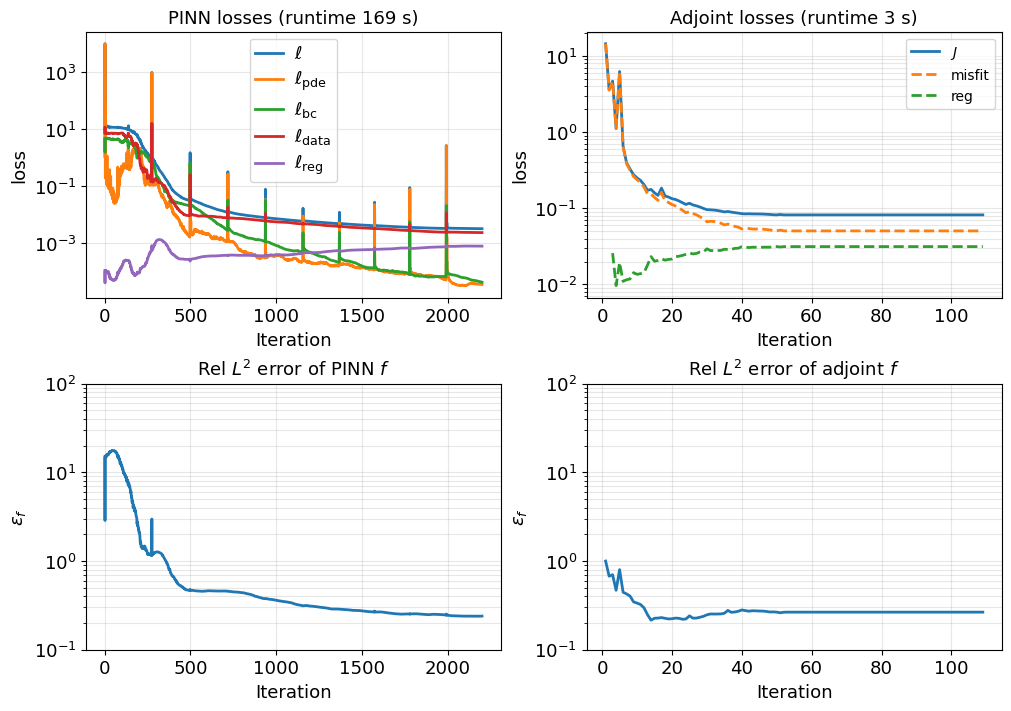

In [64]:
from matplotlib.ticker import LogLocator, LogFormatterMathtext

adjoint_path = 'history/adjoint_results_sparse.npz'
pinn_path = 'history/pinn_results_sparse.npz'

adj_blob = np.load(adjoint_path, allow_pickle=True) if os.path.exists(adjoint_path) else None
pinn_blob = np.load(pinn_path, allow_pickle=True) if os.path.exists(pinn_path) else None

if pinn_blob is not None:
    pinn_loss_full = np.asarray(pinn_blob['history_loss'], dtype=float)
    pinn_loss_pde_full = np.asarray(pinn_blob['history_loss_pde'], dtype=float)
    pinn_loss_bc_full = np.asarray(pinn_blob['history_loss_bc'], dtype=float)
    pinn_loss_data_full = np.asarray(pinn_blob['history_loss_data'], dtype=float)
    pinn_loss_reg_full = np.asarray(pinn_blob['history_loss_reg'], dtype=float)
    pinn_m_error_full = np.asarray(pinn_blob['history_m_error'], dtype=float)
    runtime_pinn = float(np.array(pinn_blob['t_bfgs']).reshape(())) if 't_bfgs' in pinn_blob.files else float(np.array(pinn_blob['t_total']).reshape(())) if 't_total' in pinn_blob.files else np.nan
    bfgs_start = int(np.array(pinn_blob['n_adam_iters']).reshape(())) if 'n_adam_iters' in pinn_blob.files else int(n_adam_iters) if 'n_adam_iters' in globals() else 0
elif 'pinn' in globals() and hasattr(pinn, 'history'):
    pinn_loss_full = np.asarray(pinn.history['loss'], dtype=float)
    pinn_loss_pde_full = np.asarray(pinn.history['loss_pde'], dtype=float)
    pinn_loss_bc_full = np.asarray(pinn.history['loss_bc'], dtype=float)
    pinn_loss_data_full = np.asarray(pinn.history['loss_data'], dtype=float)
    pinn_loss_reg_full = np.asarray(pinn.history['loss_reg'], dtype=float)
    pinn_m_error_full = np.asarray(pinn.history['m_error'], dtype=float)
    runtime_pinn = float(t_bfgs) if 't_bfgs' in globals() else float(t_adam + t_bfgs) if 't_adam' in globals() and 't_bfgs' in globals() else np.nan
    bfgs_start = int(n_adam_iters) if 'n_adam_iters' in globals() else 0
else:
    raise FileNotFoundError('Missing PINN history. Run the PINN cells or save history/pinn_results_sparse.npz first.')

bfgs_start = max(0, min(bfgs_start, len(pinn_loss_full)))
pinn_loss = pinn_loss_full[bfgs_start:]
pinn_loss_pde = pinn_loss_pde_full[bfgs_start:]
pinn_loss_bc = pinn_loss_bc_full[bfgs_start:]
pinn_loss_data = pinn_loss_data_full[bfgs_start:]
pinn_loss_reg = pinn_loss_reg_full[bfgs_start:]
pinn_m_error = pinn_m_error_full[bfgs_start:]

if adj_blob is not None:
    adj_loss = np.asarray(adj_blob['history_J'], dtype=float)
    adj_misfit = np.asarray(adj_blob['history_data_misfit'], dtype=float)
    adj_reg = np.asarray(adj_blob['history_reg_term'], dtype=float)
    runtime_adj = float(np.array(adj_blob['t_total']).reshape(())) if 't_total' in adj_blob.files else np.nan
    adj_m_error = np.asarray(adj_blob['history_m_error'], dtype=float) if 'history_m_error' in adj_blob.files else None
elif 'inv' in globals() and hasattr(inv, 'history'):
    adj_loss = np.asarray(inv.history['J'], dtype=float)
    adj_misfit = np.asarray(inv.history['data_misfit'], dtype=float)
    adj_reg = np.asarray(inv.history['reg_term'], dtype=float)
    runtime_adj = float(t_total) if 't_total' in globals() else np.nan
    adj_m_error = np.asarray(inv.history['m_error'], dtype=float) if 'm_error' in inv.history else None
else:
    raise FileNotFoundError('Missing adjoint history. Run the adjoint cells or save history/adjoint_results_sparse.npz first.')

if adj_m_error is None and 'inv' in globals() and hasattr(inv, 'history') and 'm_error' in inv.history:
    candidate = np.asarray(inv.history['m_error'], dtype=float)
    if candidate.size > 0:
        adj_m_error = candidate

pinn_iter_axis = np.arange(1, len(pinn_loss) + 1)
adj_iter_axis = np.arange(1, len(adj_loss) + 1)
reg_iter_mask = adj_iter_axis >= 3

fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)
axes = axes.ravel()
axes[0].semilogy(pinn_iter_axis, pinn_loss + 1.0e-30, lw=2, label=r'$\ell$')
axes[0].semilogy(pinn_iter_axis, pinn_loss_pde + 1.0e-30, lw=2, label=r'$\ell_{\mathrm{pde}}$')
axes[0].semilogy(pinn_iter_axis, pinn_loss_bc + 1.0e-30, lw=2, label=r'$\ell_{\mathrm{bc}}$')
axes[0].semilogy(pinn_iter_axis, pinn_loss_data + 1.0e-30, lw=2, label=r'$\ell_{\mathrm{data}}$')
if np.any(np.abs(pinn_loss_reg) > 0.0):
    axes[0].semilogy(pinn_iter_axis, pinn_loss_reg + 1.0e-30, lw=2, label=r'$\ell_{\mathrm{reg}}$')
axes[0].set_title(f'PINN losses (runtime {runtime_pinn:.0f} s)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('loss')
axes[0].legend()

axes[1].semilogy(adj_iter_axis, adj_loss + 1.0e-30, lw=2, label=r'$J$')
axes[1].semilogy(adj_iter_axis, adj_misfit + 1.0e-30, '--', lw=2, label='misfit')
if np.any(np.abs(adj_reg) > 0.0) and np.any(reg_iter_mask):
    axes[1].semilogy(adj_iter_axis[reg_iter_mask], adj_reg[reg_iter_mask] + 1.0e-30, '--', lw=2, label='reg')
axes[1].set_title(f'Adjoint losses (runtime {runtime_adj:.0f} s)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('loss')
axes[1].set_yscale('log')
axes[1].yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=100))
axes[1].yaxis.set_major_formatter(LogFormatterMathtext(base=10.0))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100))
axes[1].legend()

valid_pinn = np.isfinite(pinn_m_error) & (pinn_m_error > 0.0)
if np.any(valid_pinn):
    axes[2].semilogy(np.arange(1, len(pinn_m_error) + 1)[valid_pinn], pinn_m_error[valid_pinn], lw=2)
axes[2].set_title(r'Rel $L^2$ error of PINN $f$')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel(r'$\varepsilon_f$')

valid_adj = None if adj_m_error is None else (np.isfinite(adj_m_error) & (adj_m_error > 0.0))
if valid_adj is not None and np.any(valid_adj):
    axes[3].semilogy(np.arange(1, len(adj_m_error) + 1)[valid_adj], adj_m_error[valid_adj], lw=2)
else:
    axes[3].text(
        0.5,
        0.5,
        'Adjoint m-error history\nnot available in saved data.',
        ha='center',
        va='center',
        transform=axes[3].transAxes,
        fontsize=12,
    )
axes[3].set_title(r'Rel $L^2$ error of adjoint $f$')
axes[3].set_xlabel('Iteration')
axes[3].set_ylabel(r'$\varepsilon_f$')

error_histories = []
if np.any(valid_pinn):
    error_histories.append(pinn_m_error[valid_pinn])
if valid_adj is not None and np.any(valid_adj):
    error_histories.append(adj_m_error[valid_adj])
if error_histories:
    error_positive = np.concatenate(error_histories)
    err_ymin = 10.0 ** np.floor(np.log10(error_positive.min()))
    err_ymax = 10.0 ** np.ceil(np.log10(error_positive.max()))
    axes[2].set_ylim(err_ymin, err_ymax)
    if valid_adj is not None and np.any(valid_adj):
        axes[3].set_ylim(err_ymin, err_ymax)

for ax in axes:
    ax.grid(True, which='both', alpha=0.3)
    ax.set_title(ax.get_title(), fontsize=13)
    ax.set_xlabel(ax.get_xlabel(), fontsize=13)
    ax.set_ylabel(ax.get_ylabel(), fontsize=13)
    ax.tick_params(axis='both', which='both', labelsize=13)

legend = axes[0].get_legend()
if legend is not None:
    for text in legend.get_texts():
        text.set_fontsize(13)

fig.savefig('figures/training_history.png', bbox_inches='tight', dpi=300)
plt.show()